In [45]:
import pandas as pd
import matplotlib.pyplot as plt

agg = pd.read_csv(r"C:\Users\bfunk\Downloads\womens_aggregated_session.csv")
sessions = pd.read_csv(r"C:\Users\bfunk\Downloads\womens_soccer_select.csv")

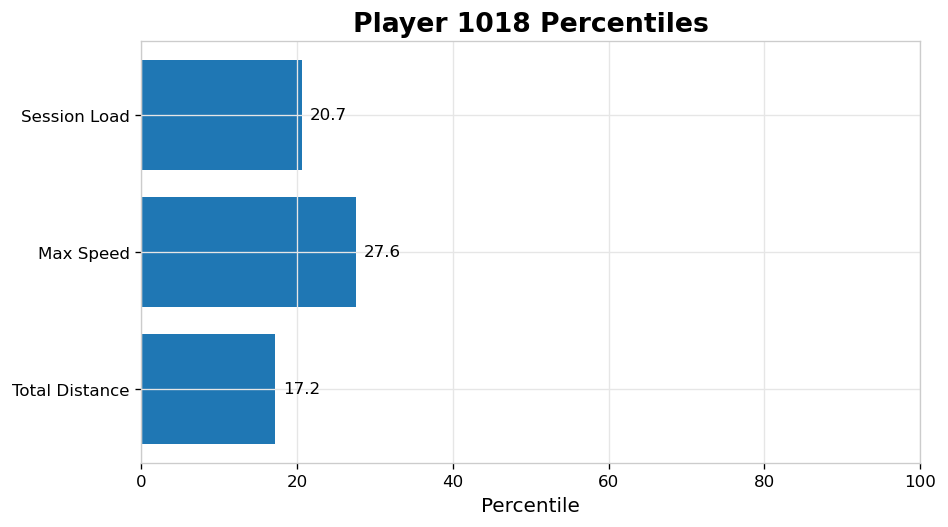

In [46]:
player_id = 1018

player = agg.loc[agg["athlete_number"] == player_id].iloc[0]

metrics = ["Total Distance", "Max Speed", "Session Load"]
percentiles = [
    player["total_dist_perc_rank"],
    player["max_speed_perc_rank"],
    player["session_load_perc_rank"]
]

plt.figure(figsize=(8, 4.5))
plt.barh(metrics, percentiles)
plt.xlim(0, 100)
plt.xlabel("Percentile")
plt.title(f"Player {player_id} Percentiles")

for i, v in enumerate(percentiles):
    plt.text(v + 1, i, f"{v:.1f}", va="center")

plt.tight_layout()
plt.show()

In [47]:
player_a = 1018
player_b = 1081

compare = agg.loc[
    agg["athlete_number"].isin([player_a, player_b]),
    ["athlete_number", "w_total_distance", "w_max_speed_kph", "w_session_load"]
].set_index("athlete_number")

print(compare)

                w_total_distance  w_max_speed_kph  w_session_load
athlete_number                                                   
1018                 3038.548302        19.773798      417.214328
1081                 4215.265913        21.609228      556.681326


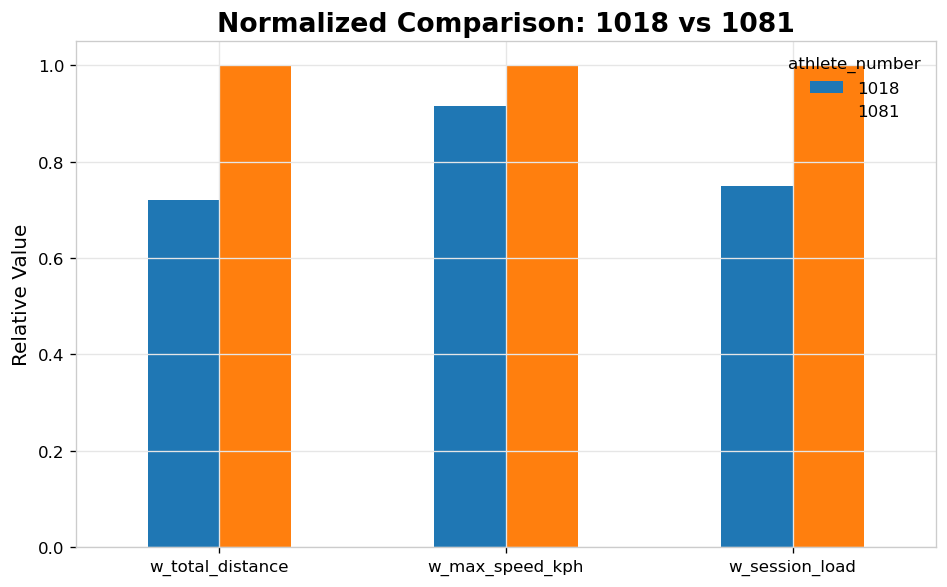

In [48]:
compare_norm = compare / compare.max()

compare_norm.T.plot(kind="bar", figsize=(8, 5))
plt.title(f"Normalized Comparison: {player_a} vs {player_b}")
plt.ylabel("Relative Value")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
agg_numeric = [
    "athlete_relative_age",
    "w_total_distance",
    "w_session_load",
    "w_max_speed_kph",
    "total_dist_perc_rank",
    "max_speed_perc_rank",
    "session_load_perc_rank",
    "num_sessions"
]

session_numeric = [
    "athlete_relative_age",
    "active_minutes",
    "total_distance_m",
    "max_speed_kph",
    "session_load",
    "total_dist_perc_rank",
    "max_speed_perc_rank",
    "session_load_perc_rank"
]

for col in agg_numeric:
    agg[col] = pd.to_numeric(agg[col], errors="coerce")

for col in session_numeric:
    sessions[col] = pd.to_numeric(sessions[col], errors="coerce")


In [50]:
print("Aggregated shape:", agg.shape)
print("Session-level shape:", sessions.shape)
print("\nAggregated columns:\n", agg.columns.tolist())
print("\nSession-level columns:\n", sessions.columns.tolist())

Aggregated shape: (94, 9)
Session-level shape: (3257, 9)

Aggregated columns:
 ['athlete_number', 'athlete_relative_age', 'w_total_distance', 'w_session_load', 'w_max_speed_kph', 'total_dist_perc_rank', 'max_speed_perc_rank', 'session_load_perc_rank', 'num_sessions']

Session-level columns:
 ['athlete_number', 'athlete_relative_age', 'active_minutes', 'total_distance_m', 'max_speed_kph', 'session_load', 'total_dist_perc_rank', 'max_speed_perc_rank', 'session_load_perc_rank']


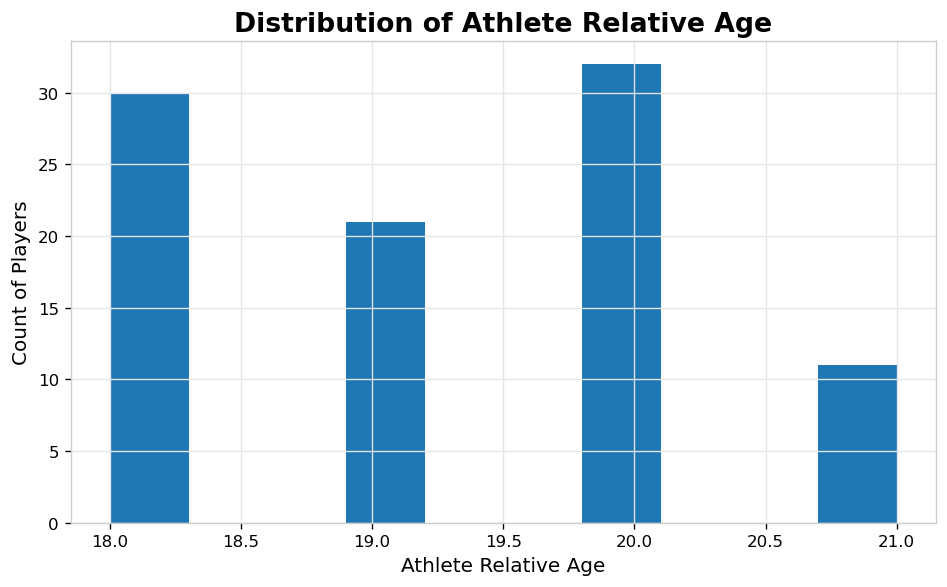

In [51]:
plt.figure(figsize=(8,5))
plt.hist(agg["athlete_relative_age"].dropna(), bins=10)
plt.title("Distribution of Athlete Relative Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Count of Players")
plt.tight_layout()
plt.show()

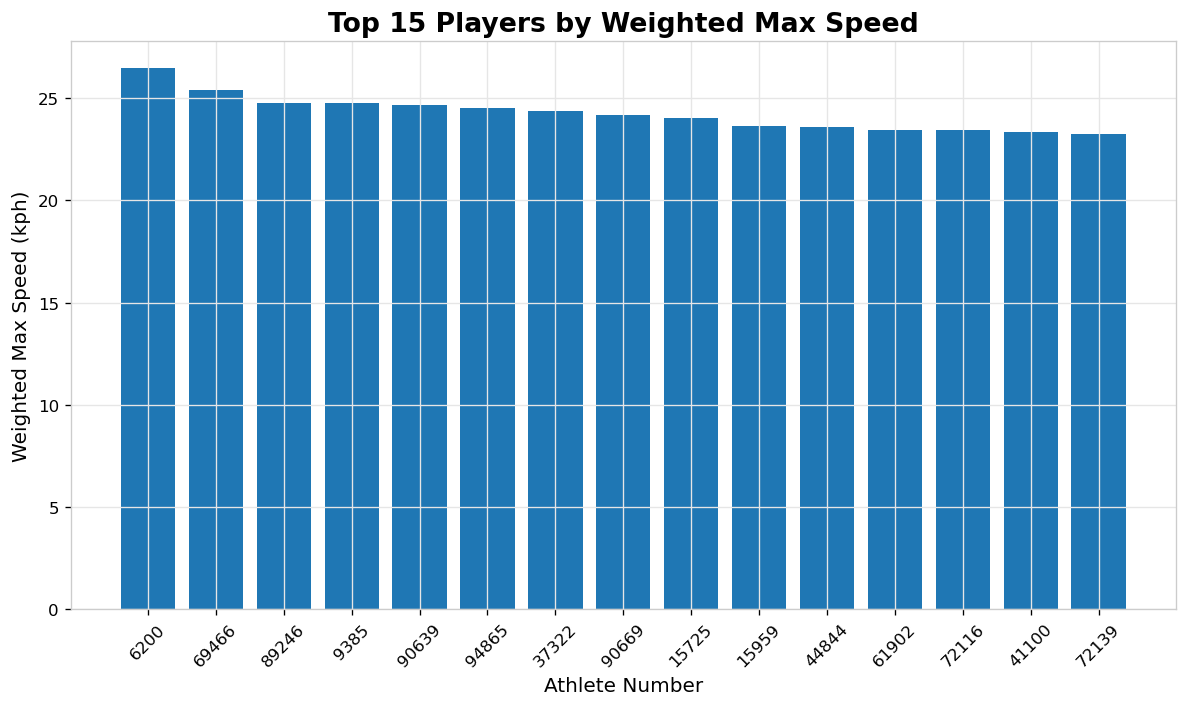

In [52]:
top_speed = agg.sort_values("w_max_speed_kph", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.bar(top_speed["athlete_number"].astype(str), top_speed["w_max_speed_kph"])
plt.title("Top 15 Players by Weighted Max Speed")
plt.xlabel("Athlete Number")
plt.ylabel("Weighted Max Speed (kph)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

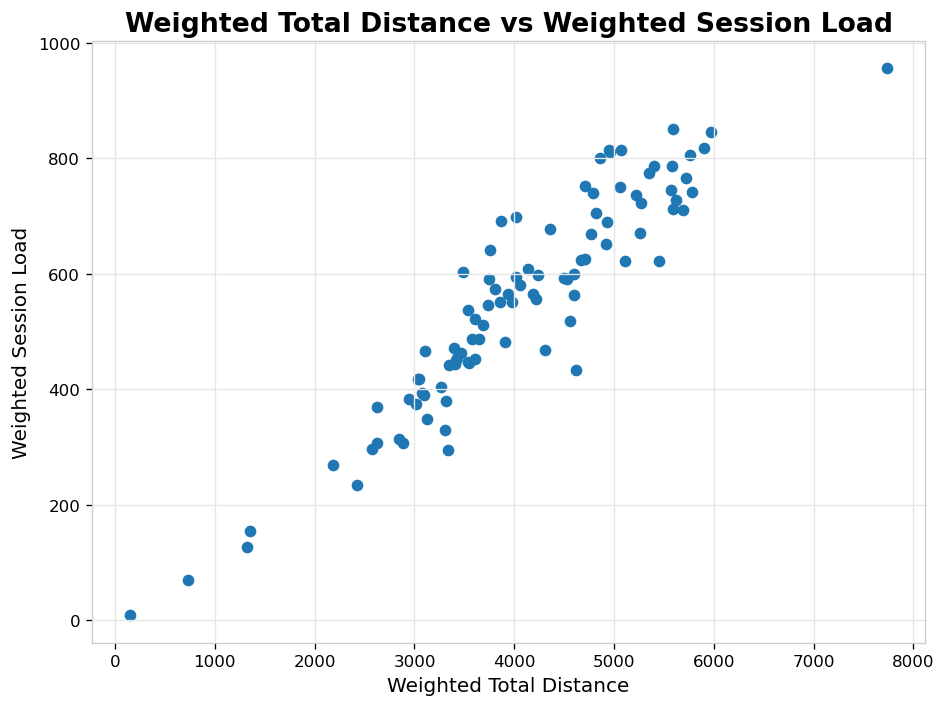

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(agg["w_total_distance"], agg["w_session_load"])
plt.title("Weighted Total Distance vs Weighted Session Load")
plt.xlabel("Weighted Total Distance")
plt.ylabel("Weighted Session Load")
plt.tight_layout()
plt.show()


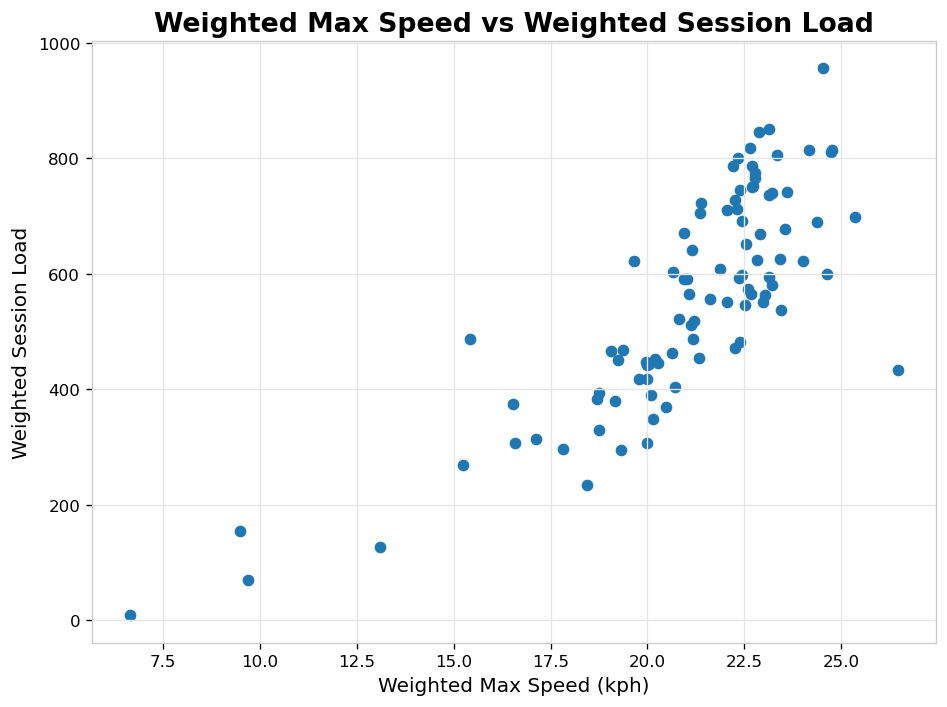

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(agg["w_max_speed_kph"], agg["w_session_load"])
plt.title("Weighted Max Speed vs Weighted Session Load")
plt.xlabel("Weighted Max Speed (kph)")
plt.ylabel("Weighted Session Load")
plt.tight_layout()
plt.show()


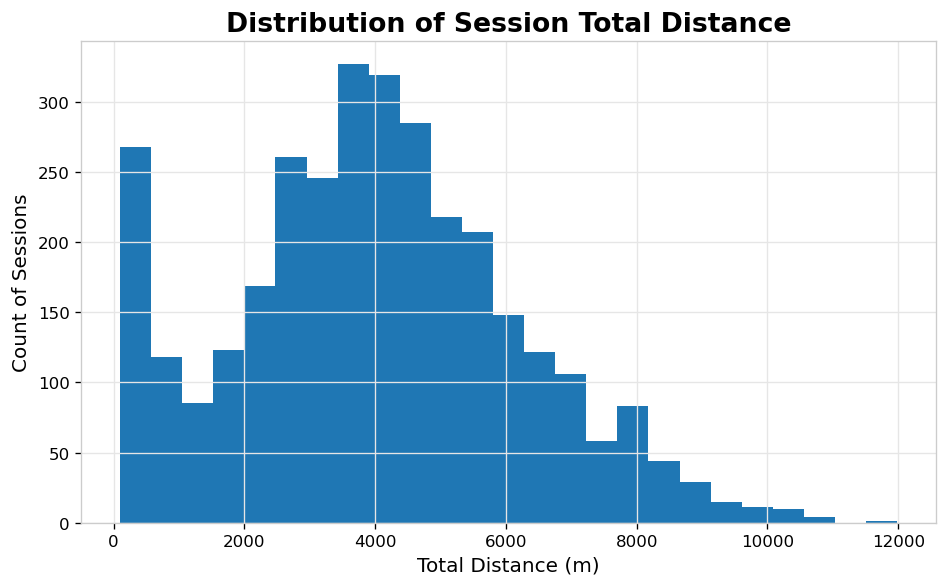

In [55]:
plt.figure(figsize=(8,5))
plt.hist(sessions["total_distance_m"].dropna(), bins=25)
plt.title("Distribution of Session Total Distance")
plt.xlabel("Total Distance (m)")
plt.ylabel("Count of Sessions")
plt.tight_layout()
plt.show()

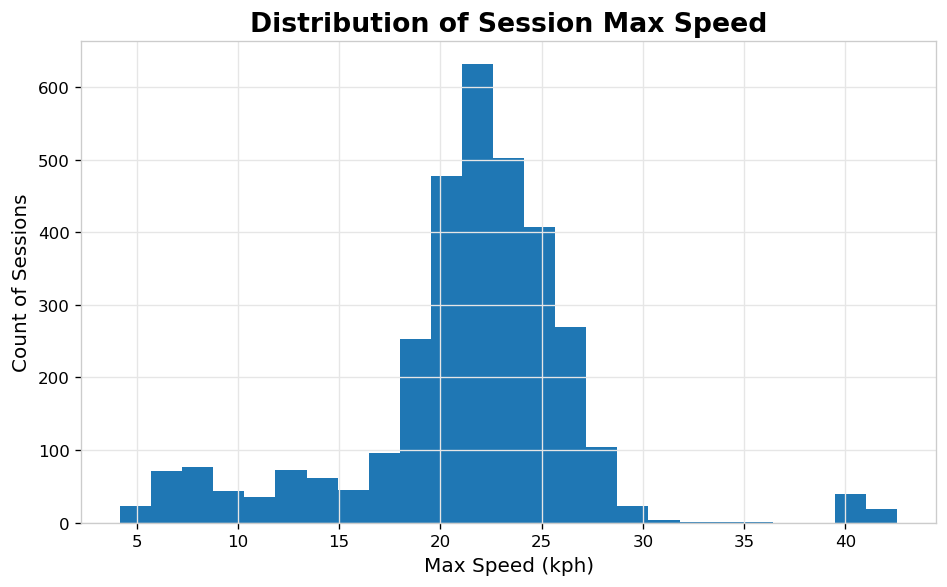

In [56]:
plt.figure(figsize=(8,5))
plt.hist(sessions["max_speed_kph"].dropna(), bins=25)
plt.title("Distribution of Session Max Speed")
plt.xlabel("Max Speed (kph)")
plt.ylabel("Count of Sessions")
plt.tight_layout()
plt.show()

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\3254559590.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


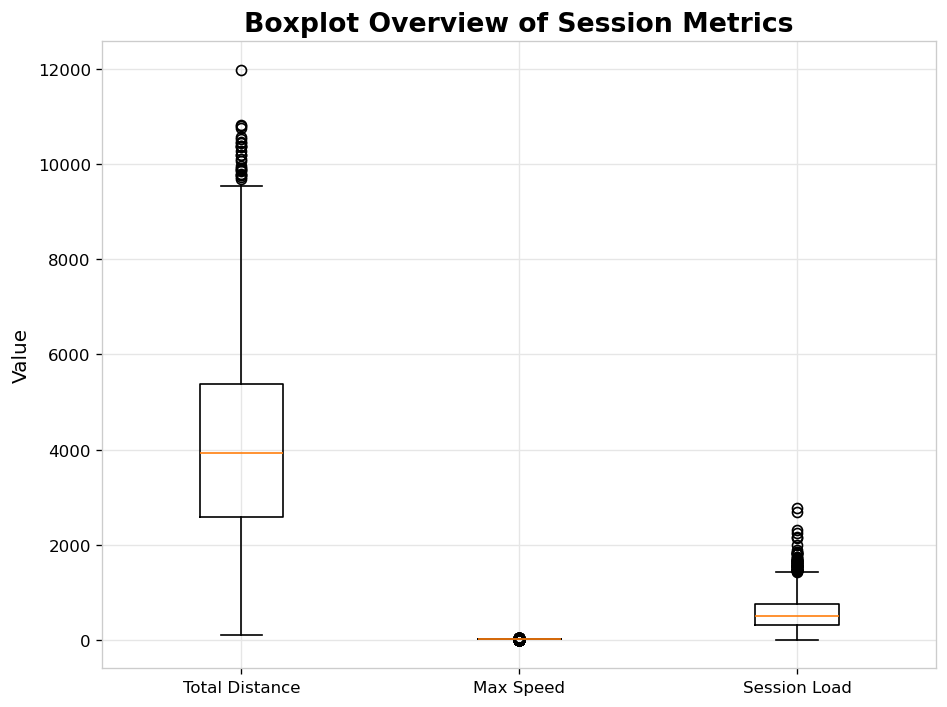

In [57]:
plt.figure(figsize=(8,6))
plt.boxplot([
    sessions["total_distance_m"].dropna(),
    sessions["max_speed_kph"].dropna(),
    sessions["session_load"].dropna()
], labels=["Total Distance", "Max Speed", "Session Load"])
plt.title("Boxplot Overview of Session Metrics")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [58]:
metrics = ["w_max_speed_kph", "w_total_distance", "w_session_load"]

for col in metrics + ["athlete_relative_age"]:
    agg[col] = pd.to_numeric(agg[col], errors="coerce")

agg = agg.dropna(subset=["athlete_relative_age"])
ages = sorted(agg["athlete_relative_age"].unique())

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\107110954.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[str(age) for age in ages])


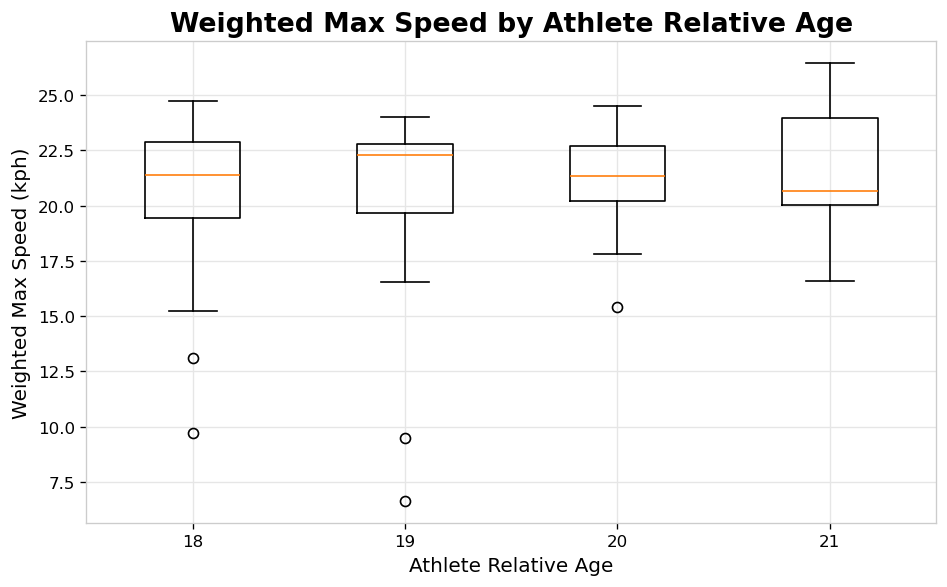

In [59]:
data_to_plot = [
    agg.loc[agg["athlete_relative_age"] == age, "w_max_speed_kph"].dropna()
    for age in ages
]

plt.figure(figsize=(8,5))
plt.boxplot(data_to_plot, labels=[str(age) for age in ages])
plt.title("Weighted Max Speed by Athlete Relative Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Weighted Max Speed (kph)")
plt.tight_layout()
plt.show()

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\24368767.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[str(age) for age in ages])


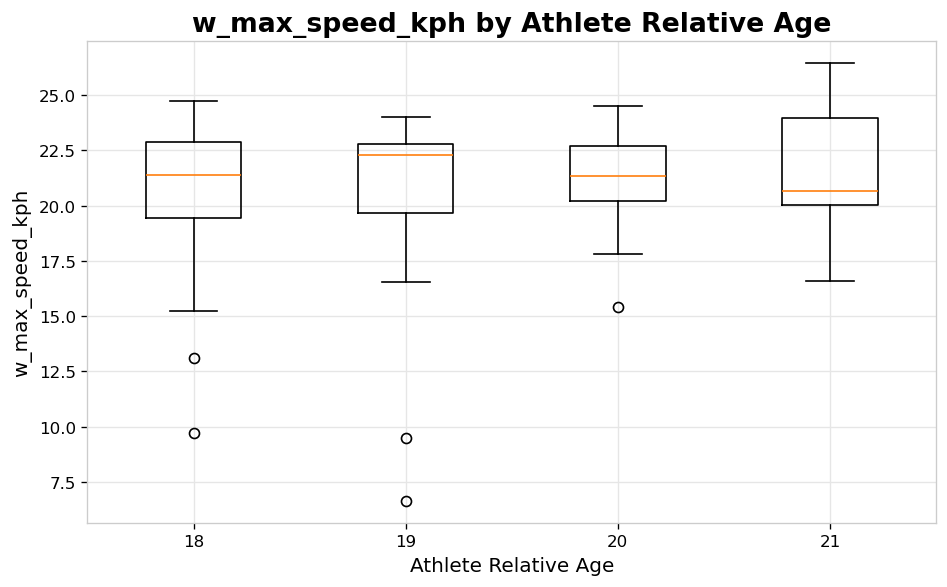

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\24368767.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[str(age) for age in ages])


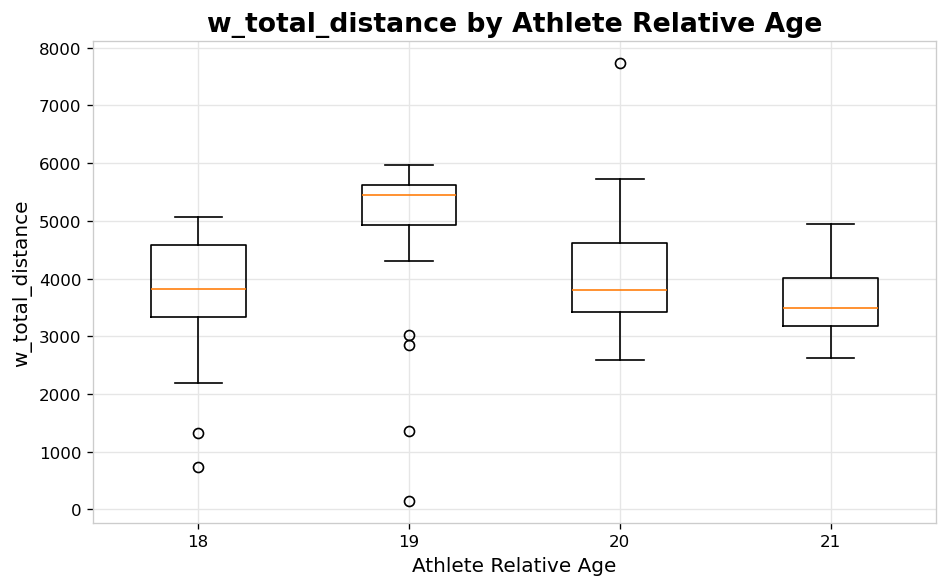

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\24368767.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[str(age) for age in ages])


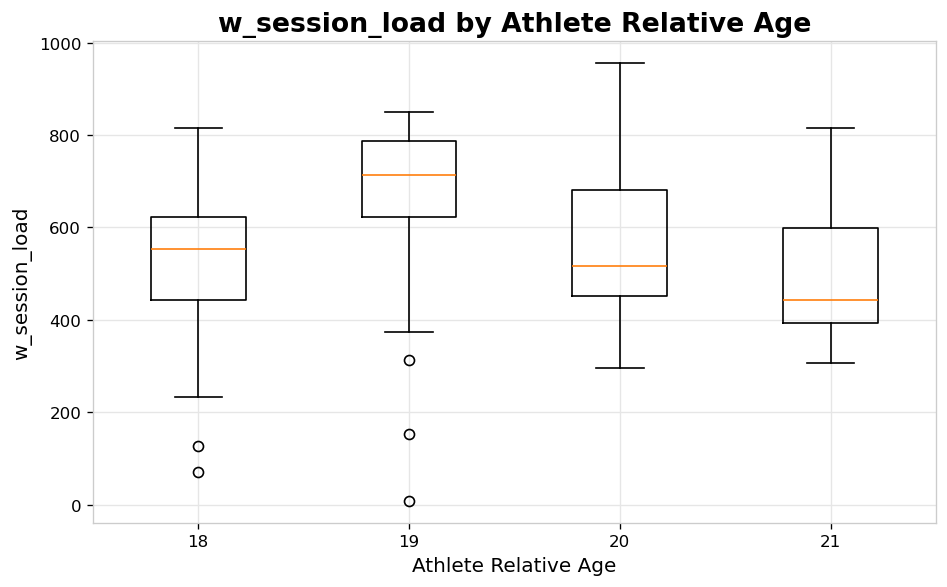

In [60]:
for metric in metrics:
    data_to_plot = [
        agg.loc[agg["athlete_relative_age"] == age, metric].dropna()
        for age in ages
    ]

    plt.figure(figsize=(8,5))
    plt.boxplot(data_to_plot, labels=[str(age) for age in ages])
    plt.title(f"{metric} by Athlete Relative Age")
    plt.xlabel("Athlete Relative Age")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\344586727.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[str(age) for age in ages])


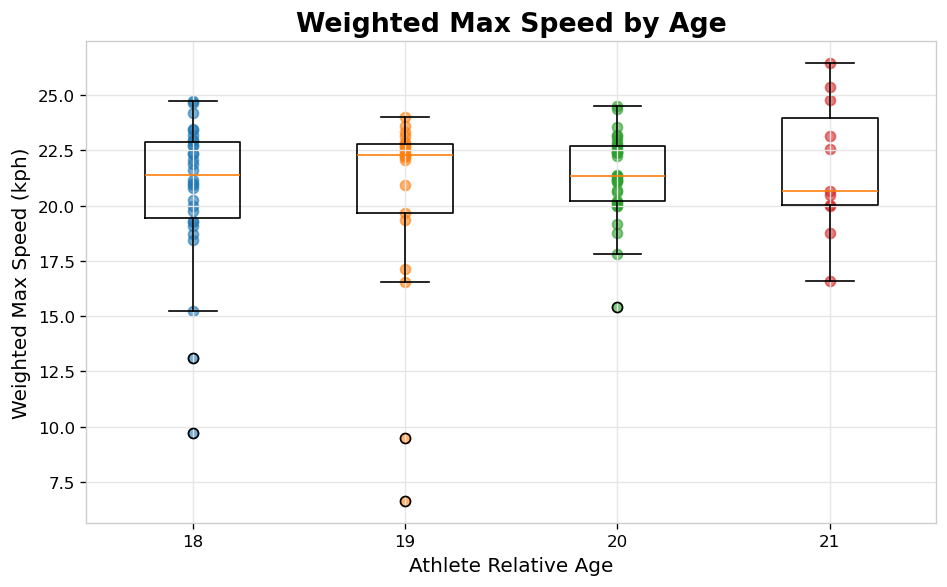

In [61]:
plt.figure(figsize=(8,5))

data_to_plot = [
    agg.loc[agg["athlete_relative_age"] == age, "w_max_speed_kph"].dropna()
    for age in ages
]

plt.boxplot(data_to_plot, labels=[str(age) for age in ages])

for i, age in enumerate(ages, start=1):
    y = agg.loc[agg["athlete_relative_age"] == age, "w_max_speed_kph"].dropna()
    x = [i] * len(y)
    plt.scatter(x, y, alpha=0.6)

plt.title("Weighted Max Speed by Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Weighted Max Speed (kph)")
plt.tight_layout()
plt.show()

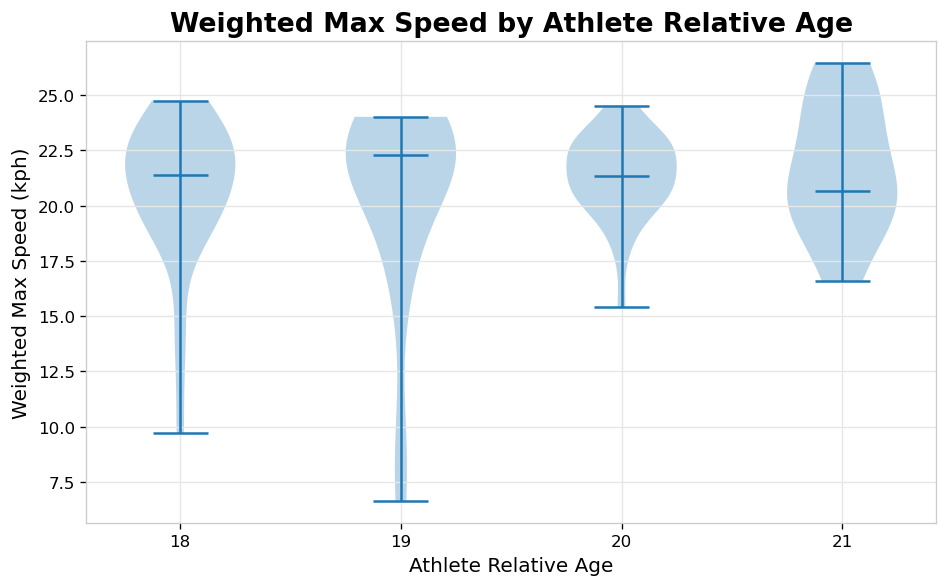

In [62]:
data_to_plot = [
    agg.loc[agg["athlete_relative_age"] == age, "w_max_speed_kph"].dropna()
    for age in ages
]

plt.figure(figsize=(8,5))
plt.violinplot(data_to_plot, showmeans=False, showmedians=True)

plt.xticks(range(1, len(ages)+1), [str(age) for age in ages])
plt.title("Weighted Max Speed by Athlete Relative Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Weighted Max Speed (kph)")
plt.tight_layout()
plt.show()

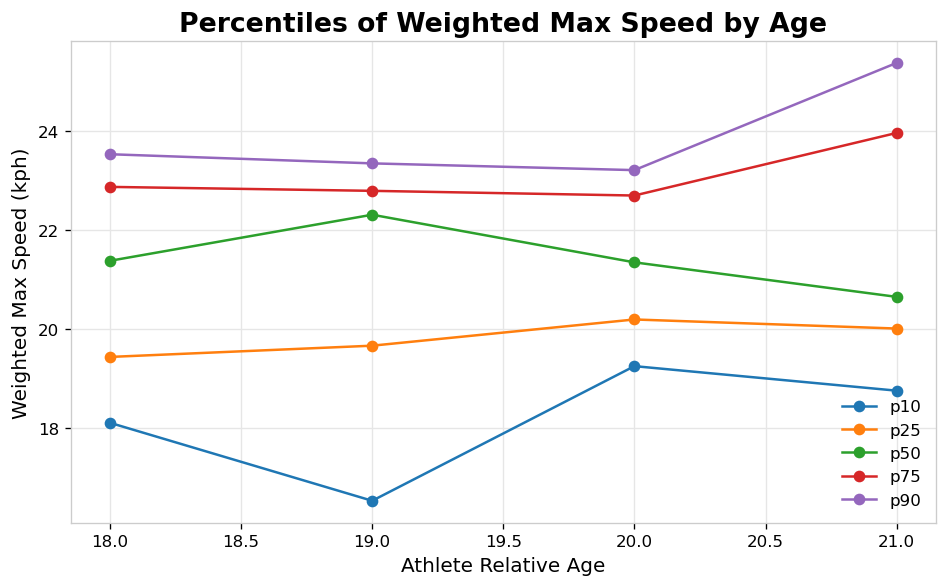

In [63]:
metric = "w_max_speed_kph"

percentile_summary = agg.groupby("athlete_relative_age")[metric].agg(
    p10=lambda x: x.quantile(0.10),
    p25=lambda x: x.quantile(0.25),
    p50=lambda x: x.quantile(0.50),
    p75=lambda x: x.quantile(0.75),
    p90=lambda x: x.quantile(0.90)
)

plt.figure(figsize=(8,5))
for col in percentile_summary.columns:
    plt.plot(percentile_summary.index, percentile_summary[col], marker='o', label=col)

plt.title("Percentiles of Weighted Max Speed by Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Weighted Max Speed (kph)")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\3459415706.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(agg[metric].dropna(), labels=["Max Speed"])


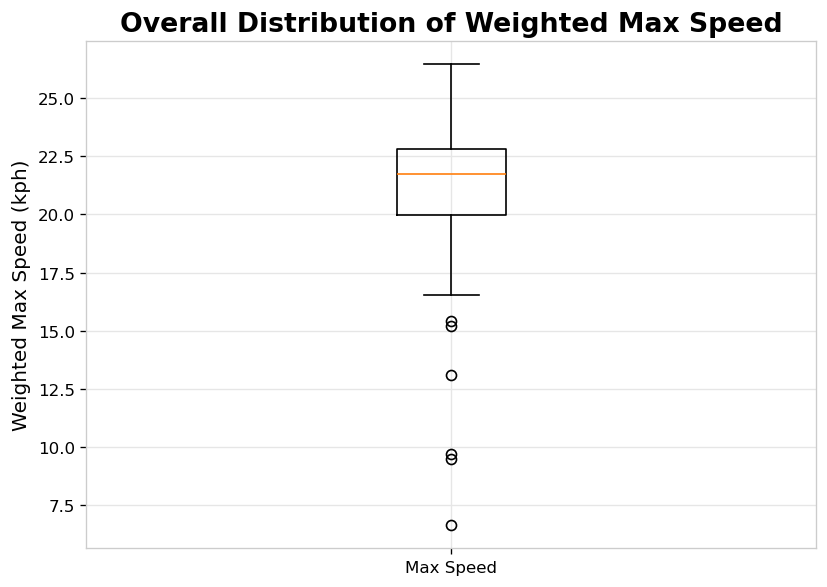

In [64]:
metric = "w_max_speed_kph"

plt.figure(figsize=(7,5))
plt.boxplot(agg[metric].dropna(), labels=["Max Speed"])
plt.title("Overall Distribution of Weighted Max Speed")
plt.ylabel("Weighted Max Speed (kph)")
plt.tight_layout()
plt.show()

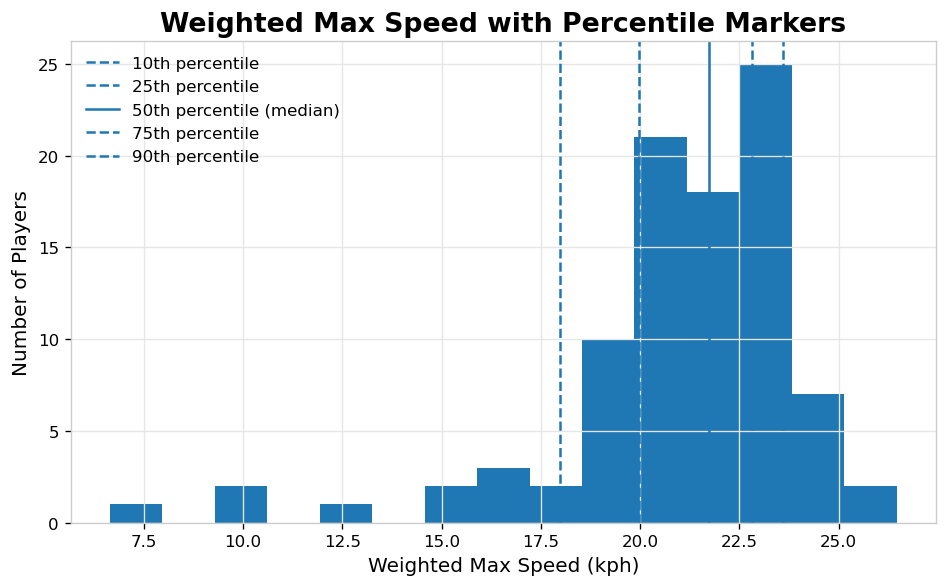

In [65]:
metric = "w_max_speed_kph"
x = agg[metric].dropna()

q10 = x.quantile(0.10)
q25 = x.quantile(0.25)
q50 = x.quantile(0.50)
q75 = x.quantile(0.75)
q90 = x.quantile(0.90)

plt.figure(figsize=(8,5))
plt.hist(x, bins=15)

plt.axvline(q10, linestyle="--", label="10th percentile")
plt.axvline(q25, linestyle="--", label="25th percentile")
plt.axvline(q50, linestyle="-",  label="50th percentile (median)")
plt.axvline(q75, linestyle="--", label="75th percentile")
plt.axvline(q90, linestyle="--", label="90th percentile")

plt.title("Weighted Max Speed with Percentile Markers")
plt.xlabel("Weighted Max Speed (kph)")
plt.ylabel("Number of Players")
plt.legend()
plt.tight_layout()
plt.show()

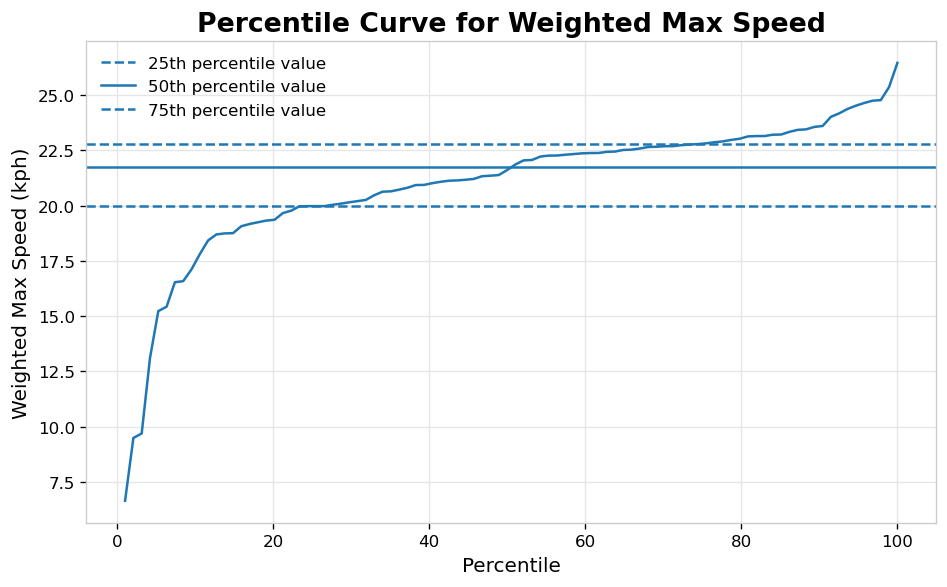

In [66]:
metric = "w_max_speed_kph"
x = agg[metric].dropna().sort_values().reset_index(drop=True)

percentiles = (x.rank(method="average", pct=True) * 100)

plt.figure(figsize=(8,5))
plt.plot(percentiles, x)
plt.axhline(x.quantile(0.25), linestyle="--", label="25th percentile value")
plt.axhline(x.quantile(0.50), linestyle="-", label="50th percentile value")
plt.axhline(x.quantile(0.75), linestyle="--", label="75th percentile value")

plt.title("Percentile Curve for Weighted Max Speed")
plt.xlabel("Percentile")
plt.ylabel("Weighted Max Speed (kph)")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\1526176546.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(x, labels=[metric])


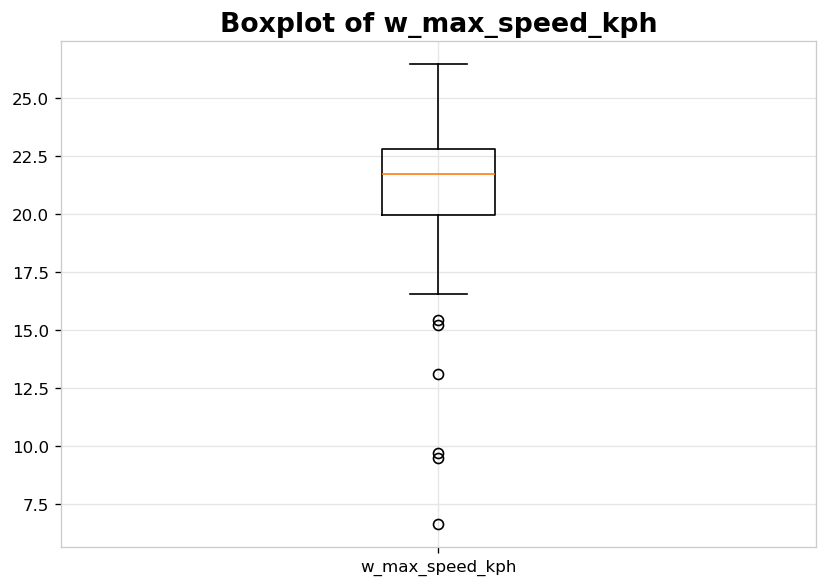

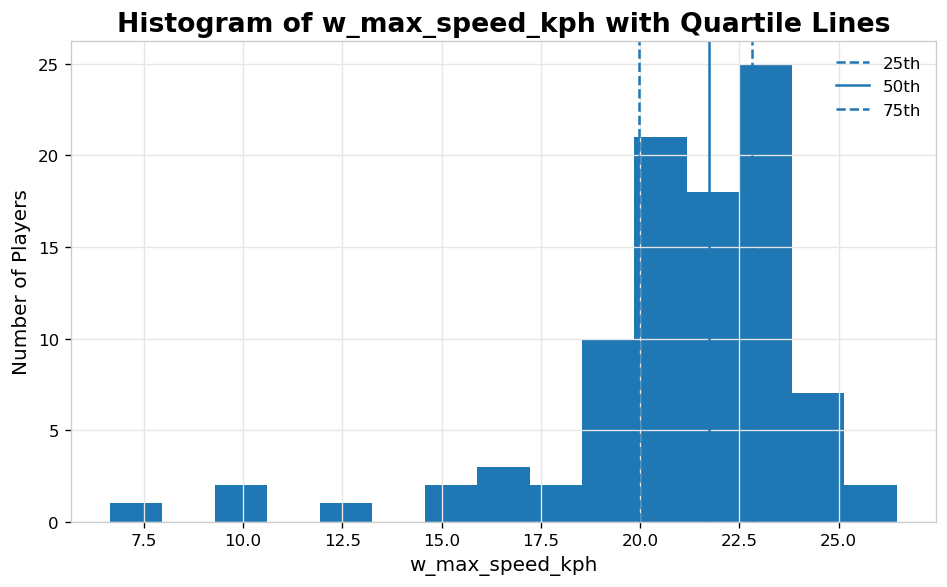

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\1526176546.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(x, labels=[metric])


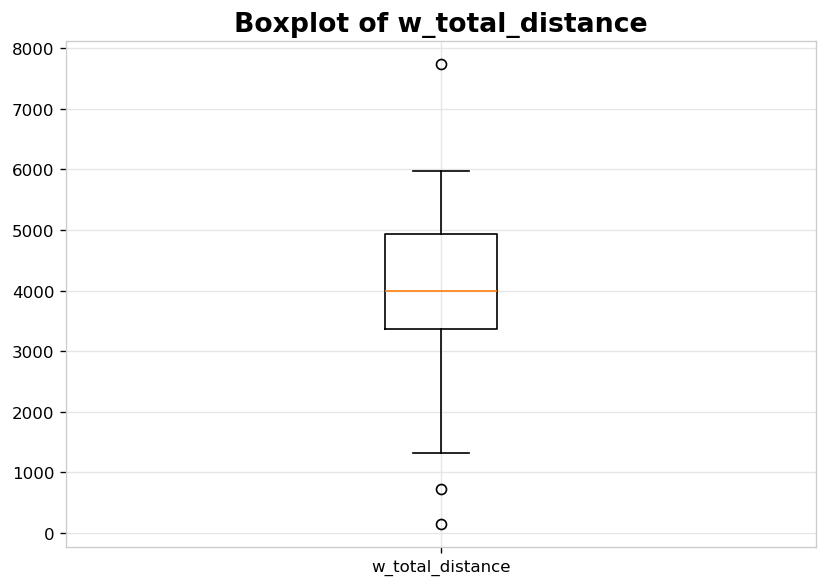

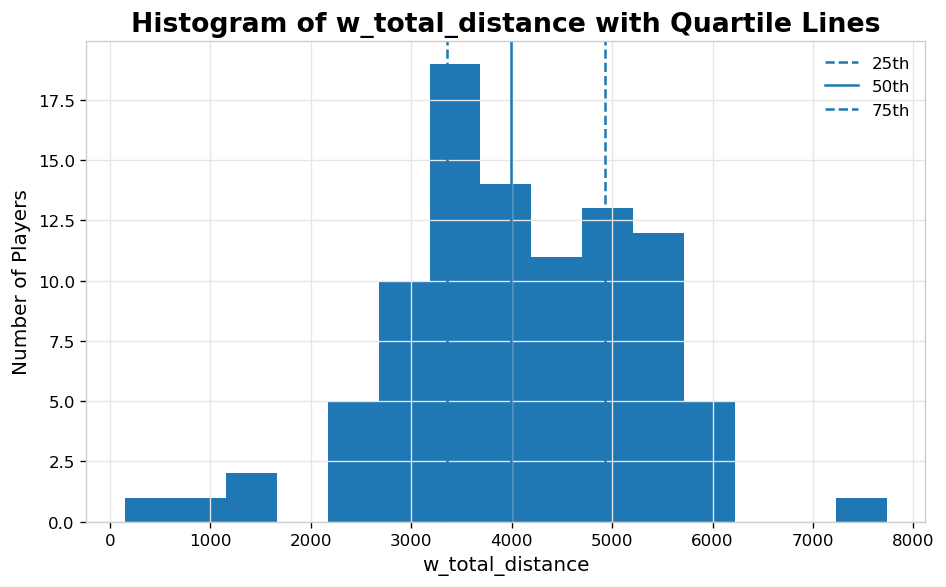

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\1526176546.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(x, labels=[metric])


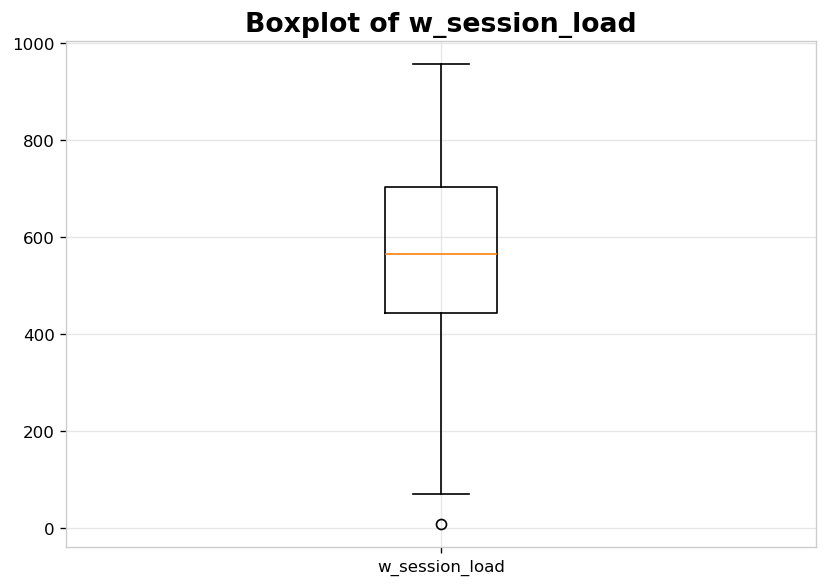

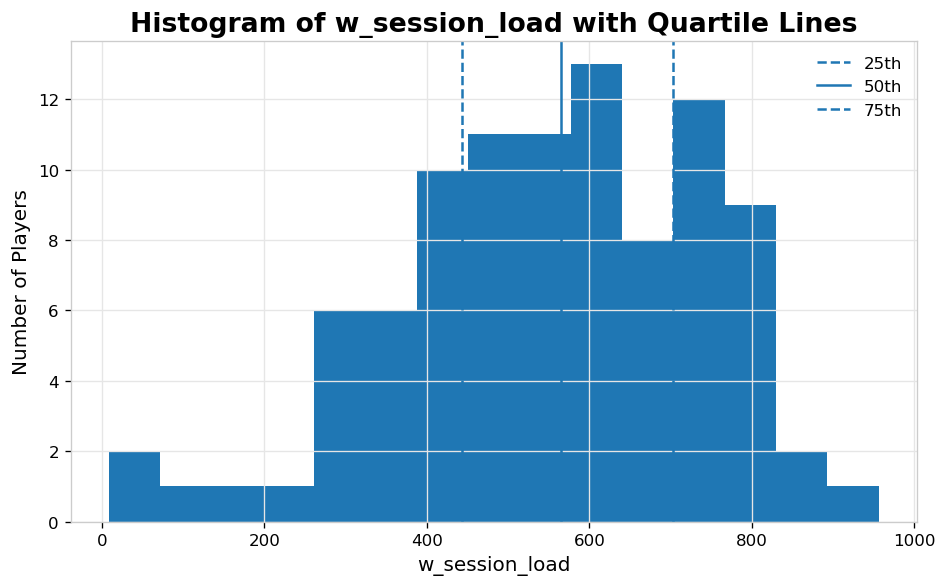

In [67]:
for metric in metrics:
    x = agg[metric].dropna()

    plt.figure(figsize=(7,5))
    plt.boxplot(x, labels=[metric])
    plt.title(f"Boxplot of {metric}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.hist(x, bins=15)
    plt.axvline(x.quantile(0.25), linestyle="--", label="25th")
    plt.axvline(x.quantile(0.50), linestyle="-", label="50th")
    plt.axvline(x.quantile(0.75), linestyle="--", label="75th")
    plt.title(f"Histogram of {metric} with Quartile Lines")
    plt.xlabel(metric)
    plt.ylabel("Number of Players")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [68]:
summary = agg[metrics].agg([
    lambda x: x.quantile(0.10),
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.50),
    lambda x: x.quantile(0.75),
    lambda x: x.quantile(0.90)
])

summary.index = ["p10", "p25", "p50", "p75", "p90"]
print(summary)

     w_max_speed_kph  w_total_distance  w_session_load
p10        17.995386       2854.927620      308.624156
p25        19.979793       3358.166891      442.572514
p50        21.736897       3997.565579      565.500179
p75        22.813217       4927.215605      703.339524
p90        23.593524       5586.403091      787.646702


In [69]:
for col in ["athlete_relative_age", "max_speed_kph", "session_load"]:
    sessions[col] = pd.to_numeric(sessions[col], errors="coerce")


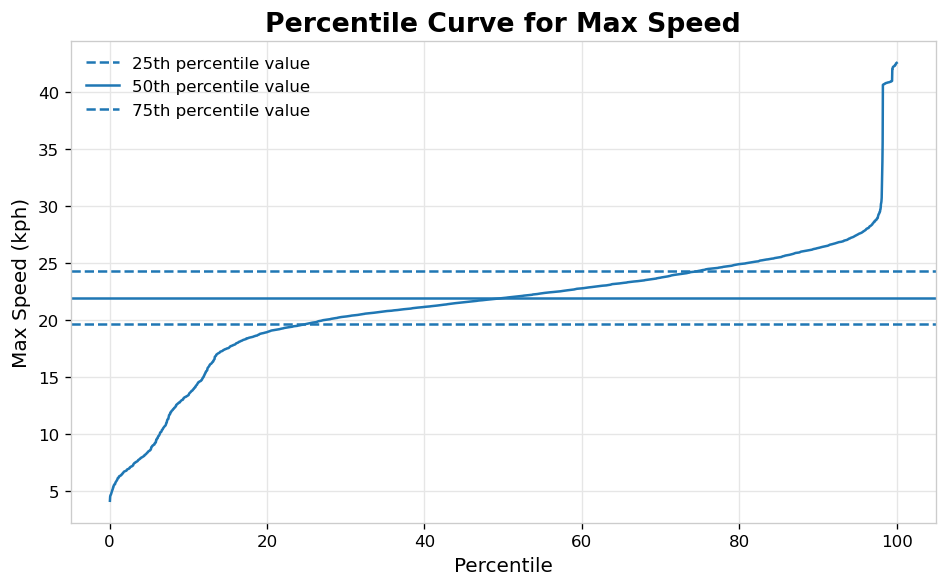

In [70]:
metric = "max_speed_kph"

x = sessions[metric].dropna().sort_values().reset_index(drop=True)
percentiles = x.rank(method="average", pct=True) * 100

plt.figure(figsize=(8,5))
plt.plot(percentiles, x)
plt.axhline(x.quantile(0.25), linestyle="--", label="25th percentile value")
plt.axhline(x.quantile(0.50), linestyle="-", label="50th percentile value")
plt.axhline(x.quantile(0.75), linestyle="--", label="75th percentile value")

plt.title("Percentile Curve for Max Speed")
plt.xlabel("Percentile")
plt.ylabel("Max Speed (kph)")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\2269455840.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[str(int(age)) for age in ages])


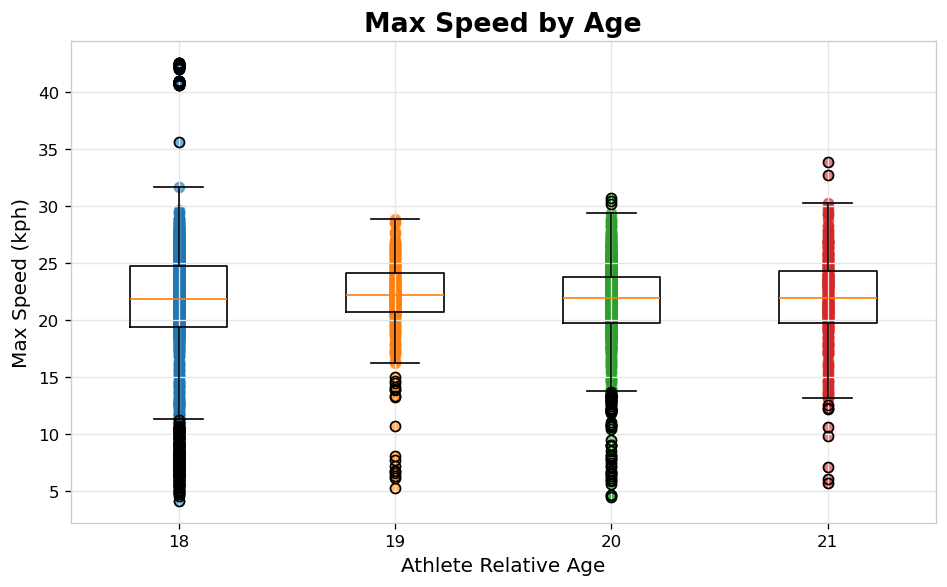

In [71]:
ages = sorted(sessions["athlete_relative_age"].dropna().unique())

plt.figure(figsize=(8,5))

data_to_plot = [
    sessions.loc[sessions["athlete_relative_age"] == age, "max_speed_kph"].dropna()
    for age in ages
]

plt.boxplot(data_to_plot, labels=[str(int(age)) for age in ages])

for i, age in enumerate(ages, start=1):
    y = sessions.loc[sessions["athlete_relative_age"] == age, "max_speed_kph"].dropna()
    x_vals = [i] * len(y)
    plt.scatter(x_vals, y, alpha=0.6)

plt.title("Max Speed by Age")
plt.xlabel("Athlete Relative Age")
plt.ylabel("Max Speed (kph)")
plt.tight_layout()
plt.show()

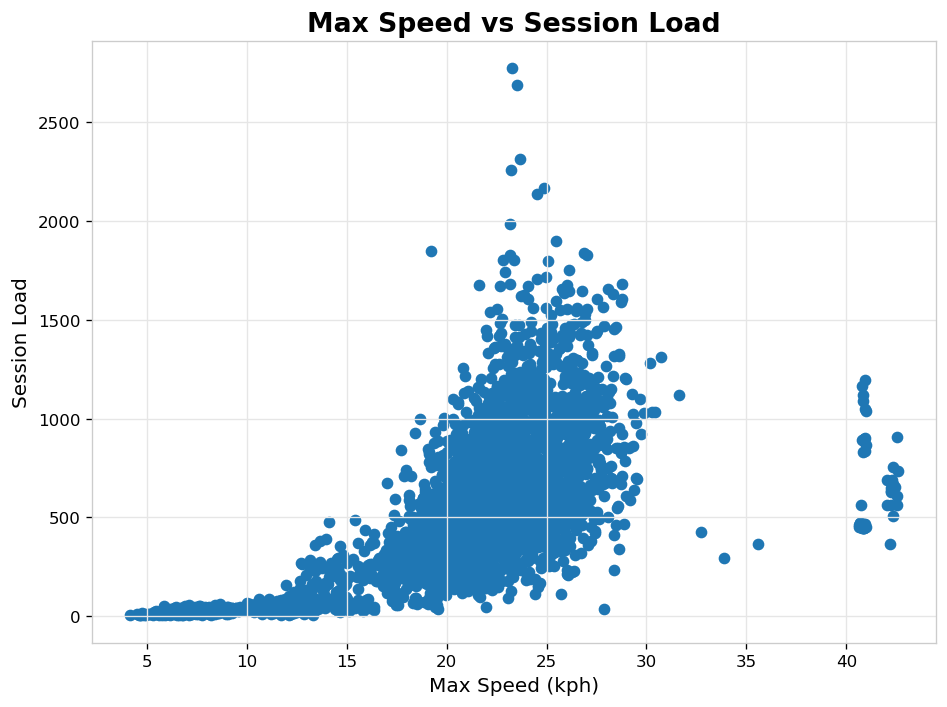

In [72]:
plt.figure(figsize=(8,6))
plt.scatter(sessions["max_speed_kph"], sessions["session_load"])
plt.title("Max Speed vs Session Load")
plt.xlabel("Max Speed (kph)")
plt.ylabel("Session Load")
plt.tight_layout()
plt.show()

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.edgecolor": "#CCCCCC",
    "axes.linewidth": 0.8,
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linestyle": "-",
    "grid.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False
})

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.grid(axis="y", alpha=0.6)
    ax.set_axisbelow(True)

label_map = {
    "w_total_distance": "Weighted Total Distance",
    "w_max_speed_kph": "Weighted Max Speed (kph)",
    "w_session_load": "Weighted Session Load",
    "total_dist_perc_rank": "Total Distance Percentile",
    "max_speed_perc_rank": "Max Speed Percentile",
    "session_load_perc_rank": "Session Load Percentile",
    "max_speed_kph": "Max Speed (kph)",
    "session_load": "Session Load",
    "total_distance_m": "Total Distance (m)"
}

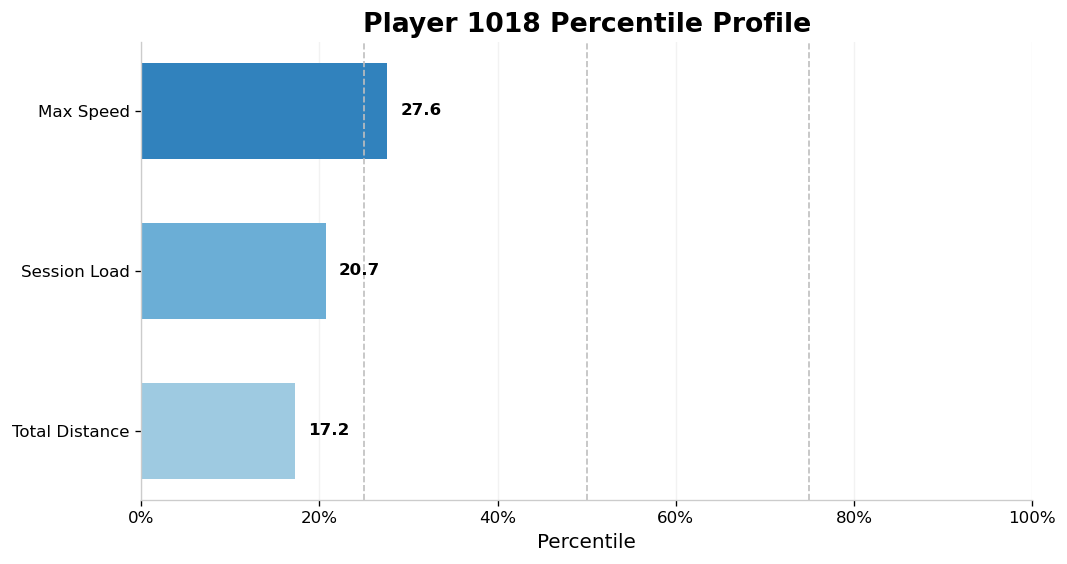

In [74]:
player_id = 1018

player = agg.loc[agg["athlete_number"] == player_id].iloc[0]

plot_data = {
    "Total Distance": player["total_dist_perc_rank"],
    "Max Speed": player["max_speed_perc_rank"],
    "Session Load": player["session_load_perc_rank"]
}

labels = list(plot_data.keys())
values = list(plot_data.values())

order = np.argsort(values)
labels = [labels[i] for i in order]
values = [values[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.barh(labels, values, color=["#9ECAE1", "#6BAED6", "#3182BD"], height=0.6)

ax.set_xlim(0, 100)
ax.set_xlabel("Percentile")
ax.set_title(f"Player {player_id} Percentile Profile")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))

for x in [25, 50, 75]:
    ax.axvline(x, color="#BFBFBF", linestyle="--", linewidth=1)

for bar, val in zip(bars, values):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=10, fontweight="bold")

clean_axes(ax)
ax.grid(axis="x", alpha=0.5)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\3992963662.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


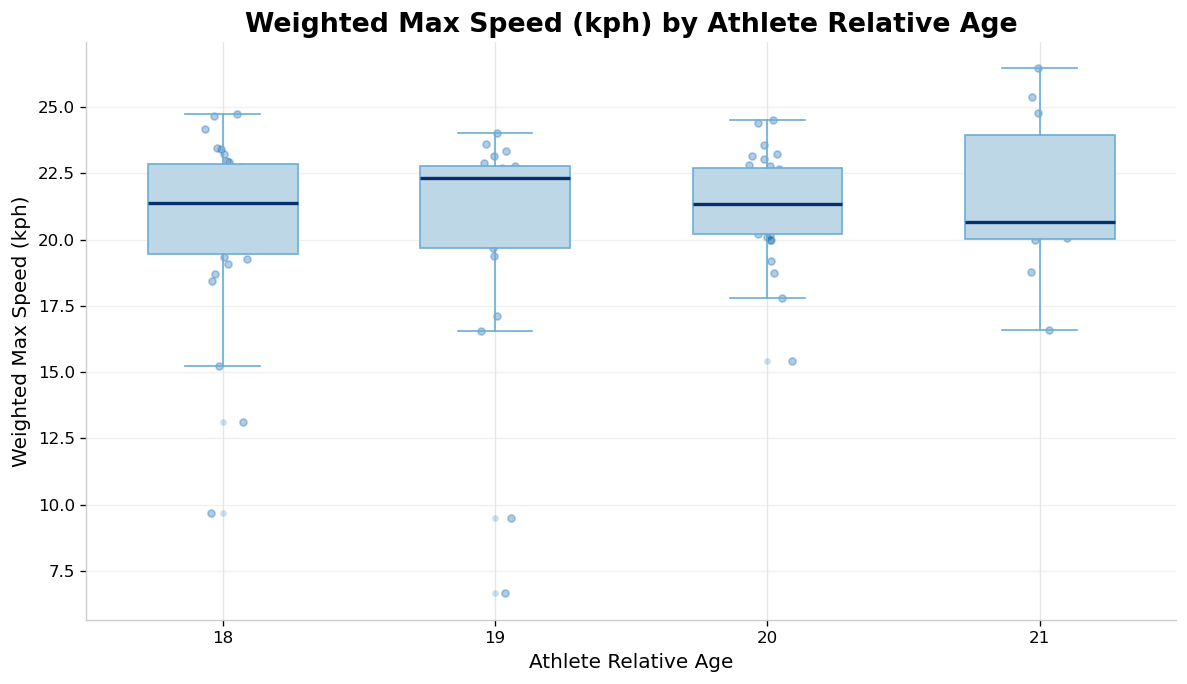

In [75]:
metric = "w_max_speed_kph"
metric_label = label_map[metric]

ages = sorted(agg["athlete_relative_age"].dropna().unique())

data_to_plot = [
    agg.loc[agg["athlete_relative_age"] == age, metric].dropna()
    for age in ages
]

fig, ax = plt.subplots(figsize=(10, 5.8))

bp = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    labels=[str(int(age)) for age in ages],
    widths=0.55,
    medianprops=dict(color="#08306B", linewidth=2),
    boxprops=dict(facecolor="#BDD7E7", edgecolor="#6BAED6"),
    whiskerprops=dict(color="#6BAED6"),
    capprops=dict(color="#6BAED6"),
    flierprops=dict(marker='o', markersize=4, markerfacecolor="#3182BD", alpha=0.25, markeredgecolor="none")
)

for i, age in enumerate(ages, start=1):
    y = agg.loc[agg["athlete_relative_age"] == age, metric].dropna().values
    x = np.random.normal(i, 0.05, size=len(y))
    ax.scatter(x, y, alpha=0.35, s=18, color="#2171B5")

ax.set_title(f"{metric_label} by Athlete Relative Age")
ax.set_xlabel("Athlete Relative Age")
ax.set_ylabel(metric_label)

clean_axes(ax)
plt.tight_layout()
plt.show()

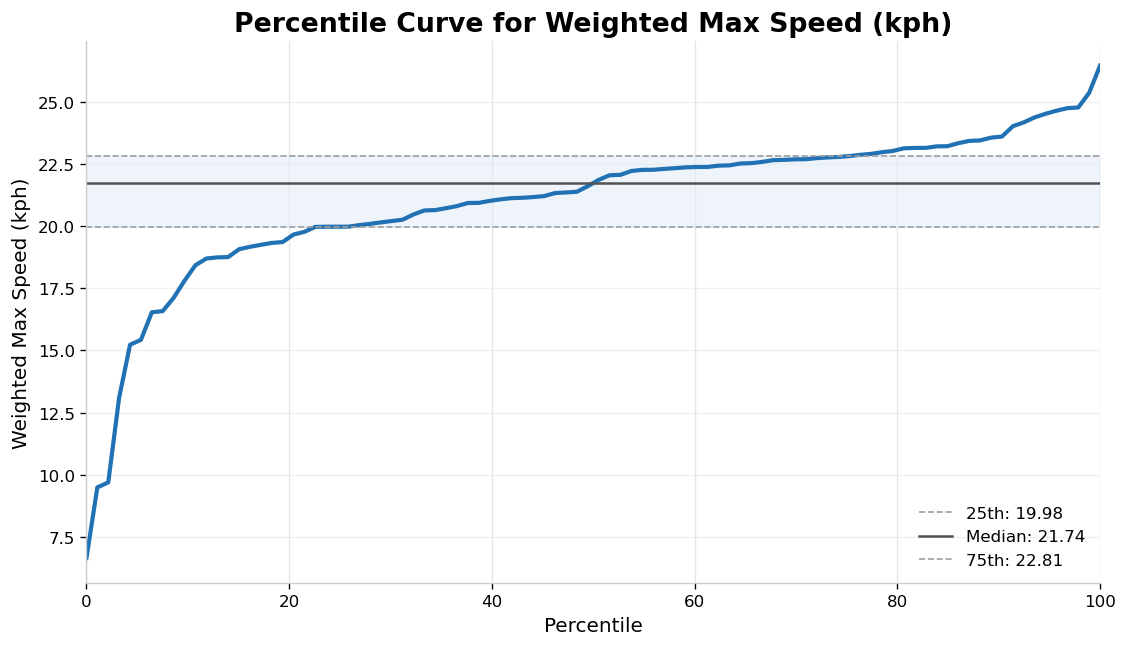

In [76]:
metric = "w_max_speed_kph"
metric_label = label_map[metric]

x = agg[metric].dropna().sort_values().reset_index(drop=True)
percentiles = np.linspace(0, 100, len(x))

q25 = x.quantile(0.25)
q50 = x.quantile(0.50)
q75 = x.quantile(0.75)

fig, ax = plt.subplots(figsize=(9.5, 5.5))

ax.plot(percentiles, x, color="#2171B5", linewidth=2.5)

ax.axhline(q25, color="#9E9E9E", linestyle="--", linewidth=1, label=f"25th: {q25:.2f}")
ax.axhline(q50, color="#525252", linestyle="-", linewidth=1.5, label=f"Median: {q50:.2f}")
ax.axhline(q75, color="#9E9E9E", linestyle="--", linewidth=1, label=f"75th: {q75:.2f}")

ax.fill_between(percentiles, q25, q75, color="#DEEBF7", alpha=0.5)

ax.set_title(f"Percentile Curve for {metric_label}")
ax.set_xlabel("Percentile")
ax.set_ylabel(metric_label)
ax.set_xlim(0, 100)

clean_axes(ax)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

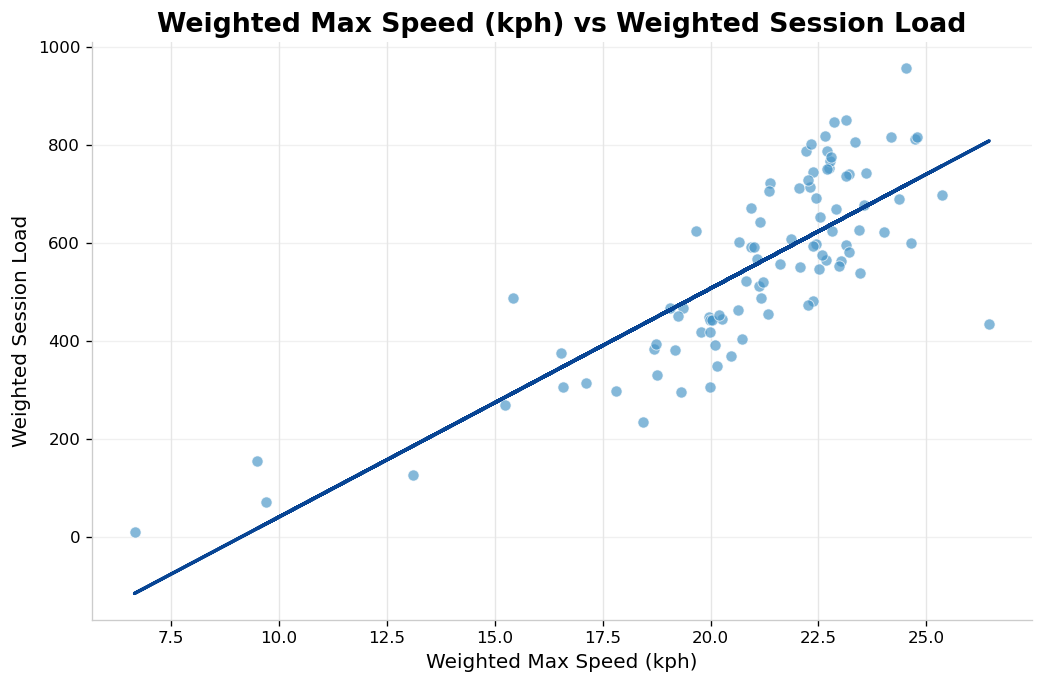

In [77]:
x_col = "w_max_speed_kph"
y_col = "w_session_load"

plot_df = agg[[x_col, y_col]].dropna()

x = plot_df[x_col]
y = plot_df[y_col]

m, b = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(8.8, 5.8))

ax.scatter(x, y, s=45, alpha=0.65, color="#4292C6", edgecolor="white", linewidth=0.6)
ax.plot(x, m*x + b, color="#084594", linewidth=2)

ax.set_title(f"{label_map[x_col]} vs {label_map[y_col]}")
ax.set_xlabel(label_map[x_col])
ax.set_ylabel(label_map[y_col])

clean_axes(ax)
plt.tight_layout()
plt.show()

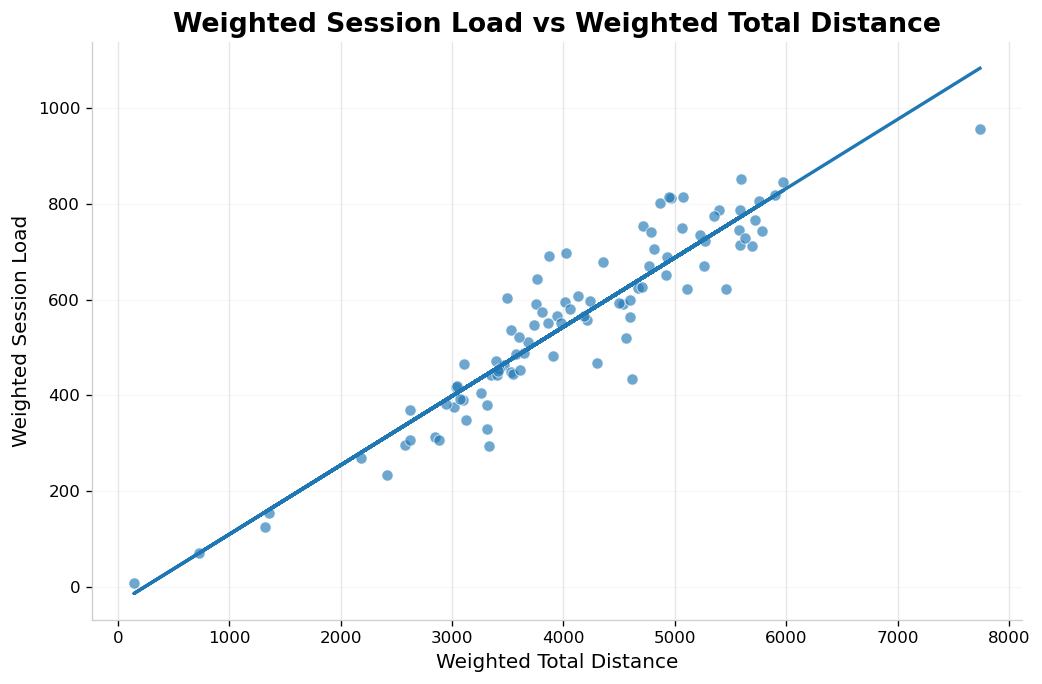

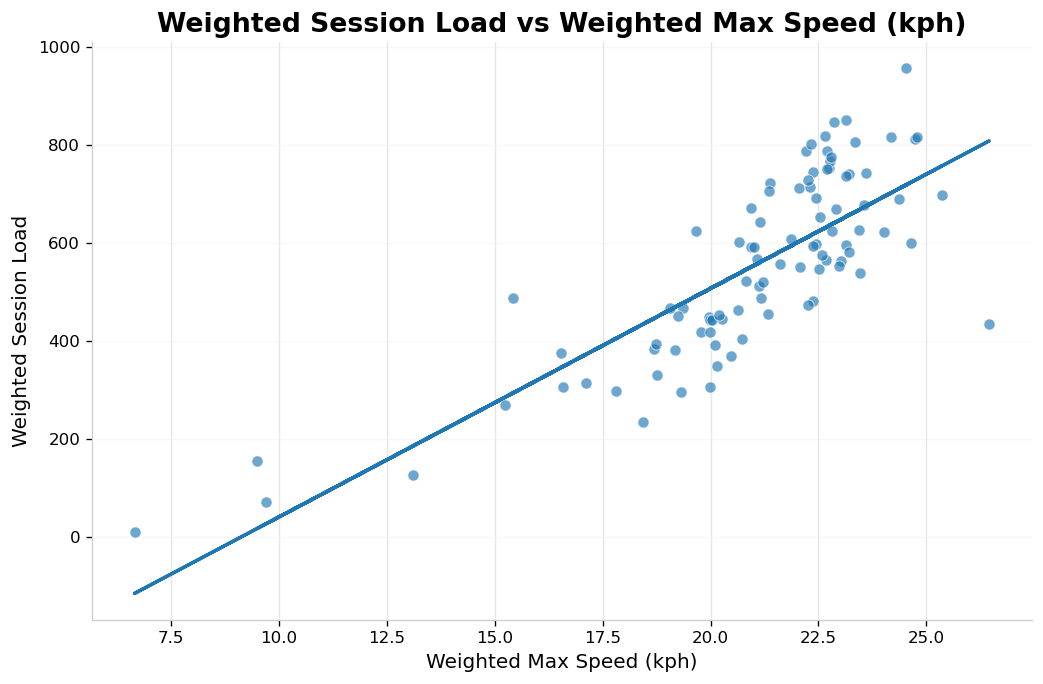

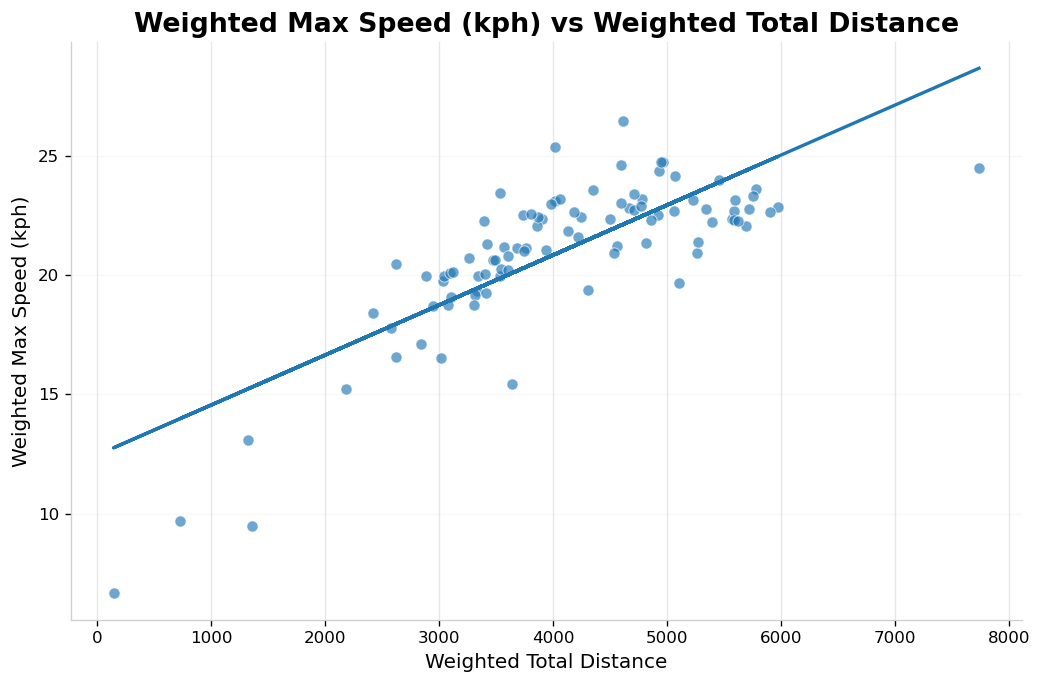

In [79]:
scatter_pairs = [
    ("w_total_distance", "w_session_load"),
    ("w_max_speed_kph", "w_session_load"),
    ("w_total_distance", "w_max_speed_kph"),
]

for x_col, y_col in scatter_pairs:
    plot_df = agg[[x_col, y_col]].dropna()

    x = plot_df[x_col]
    y = plot_df[y_col]

    m, b = np.polyfit(x, y, 1)

    fig, ax = plt.subplots(figsize=(8.8, 5.8))

    ax.scatter(x, y, s=45, alpha=0.65, edgecolor="white", linewidth=0.6)
    ax.plot(x, m * x + b, linewidth=2)

    ax.set_title(f"{label_map[y_col]} vs {label_map[x_col]}")
    ax.set_xlabel(label_map[x_col])
    ax.set_ylabel(label_map[y_col])

    clean_axes(ax)
    plt.tight_layout()
    plt.show()

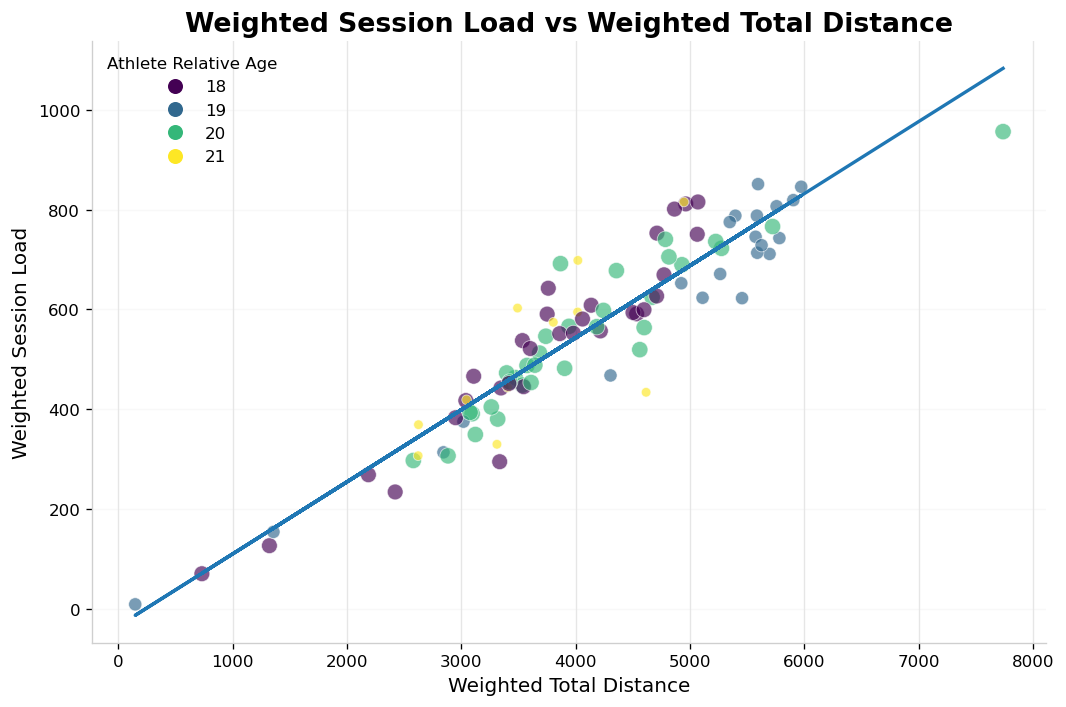

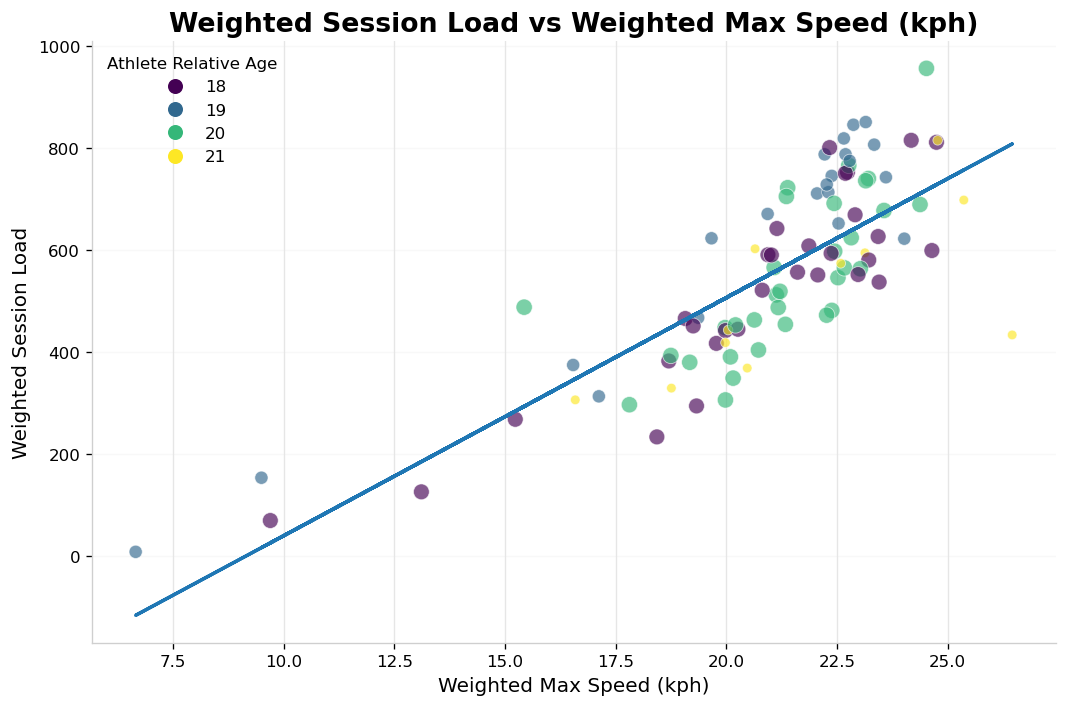

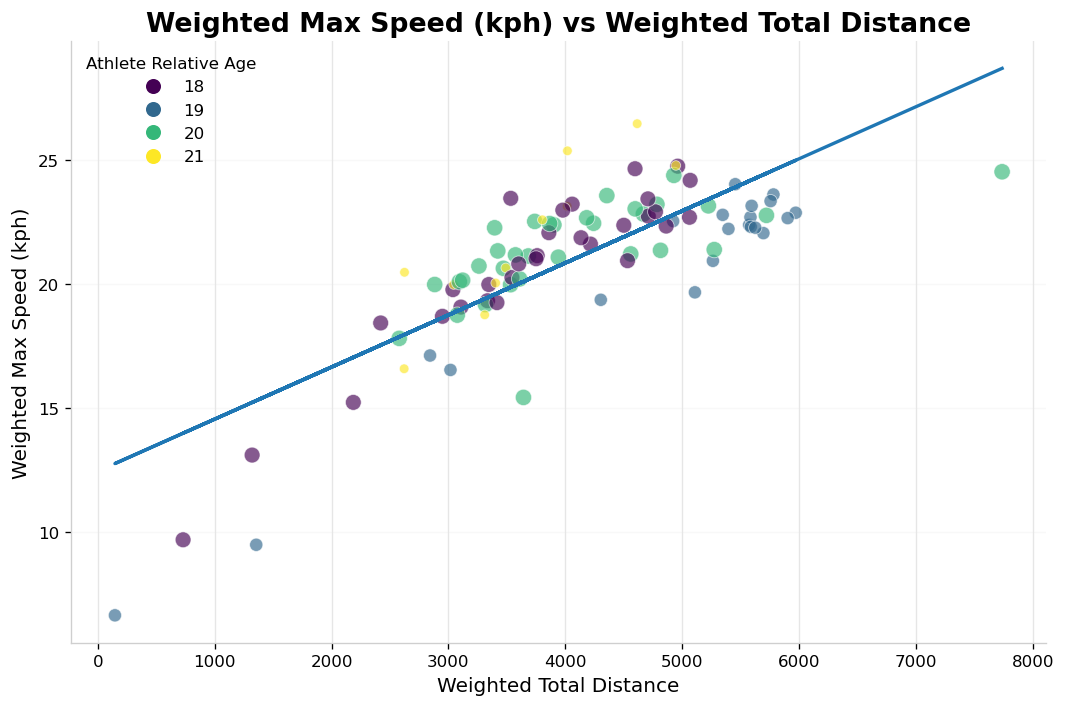

In [80]:
import matplotlib.lines as mlines

scatter_pairs = [
    ("w_total_distance", "w_session_load"),
    ("w_max_speed_kph", "w_session_load"),
    ("w_total_distance", "w_max_speed_kph"),
]

for x_col, y_col in scatter_pairs:
    plot_df = agg[[x_col, y_col, "athlete_relative_age", "num_sessions"]].dropna()

    fig, ax = plt.subplots(figsize=(9, 6))

    sc = ax.scatter(
        plot_df[x_col],
        plot_df[y_col],
        c=plot_df["athlete_relative_age"],
        s=plot_df["num_sessions"] * 3,
        alpha=0.65,
        edgecolor="white",
        linewidth=0.5
    )

    m, b = np.polyfit(plot_df[x_col], plot_df[y_col], 1)
    ax.plot(plot_df[x_col], m * plot_df[x_col] + b, linewidth=2)

    # Create discrete legend for age values
    ages = sorted(plot_df["athlete_relative_age"].unique())
    handles = [
        mlines.Line2D(
            [], [], 
            color=sc.cmap(sc.norm(age)),
            marker='o',
            linestyle='None',
            markersize=8,
            label=str(age)
        )
        for age in ages
    ]
    ax.legend(handles=handles, title="Athlete Relative Age")

    ax.set_title(f"{label_map[y_col]} vs {label_map[x_col]}")
    ax.set_xlabel(label_map[x_col])
    ax.set_ylabel(label_map[y_col])

    clean_axes(ax)
    plt.tight_layout()
    plt.show()

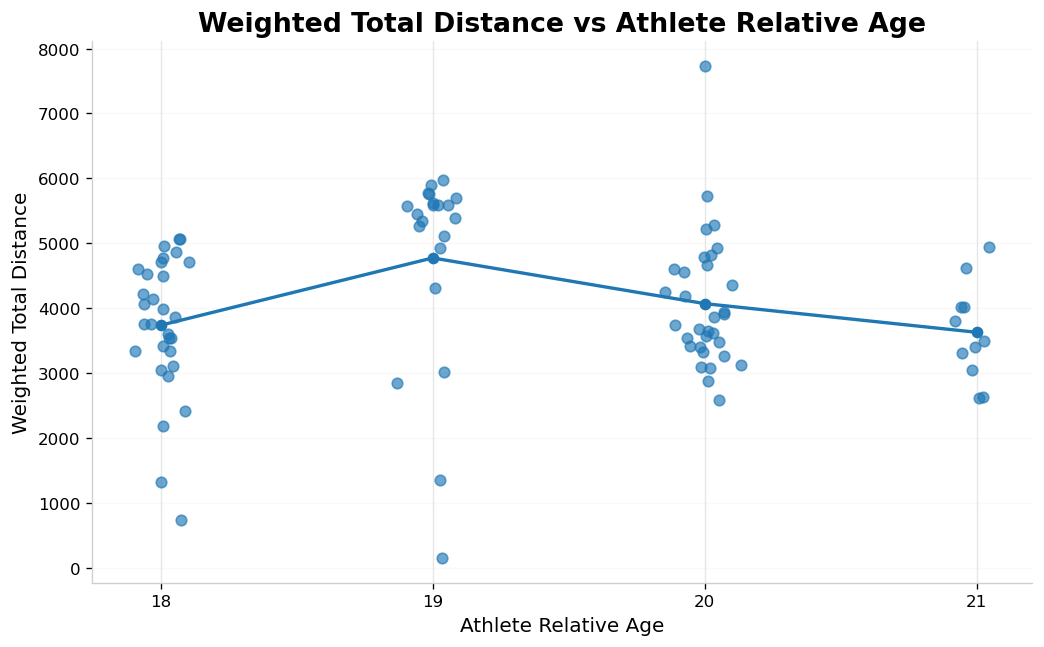

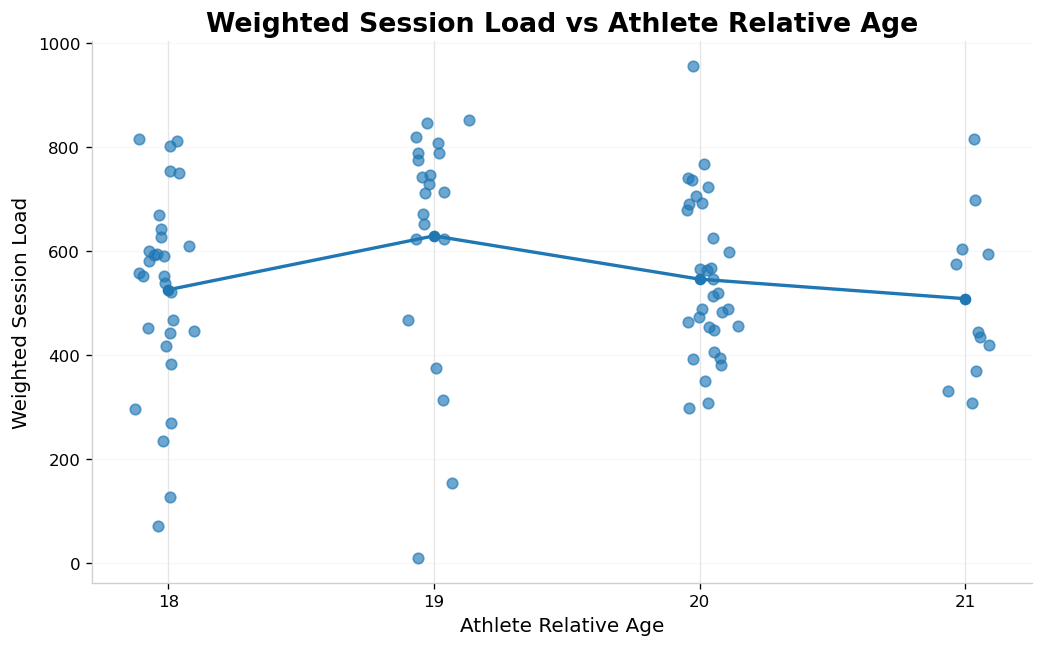

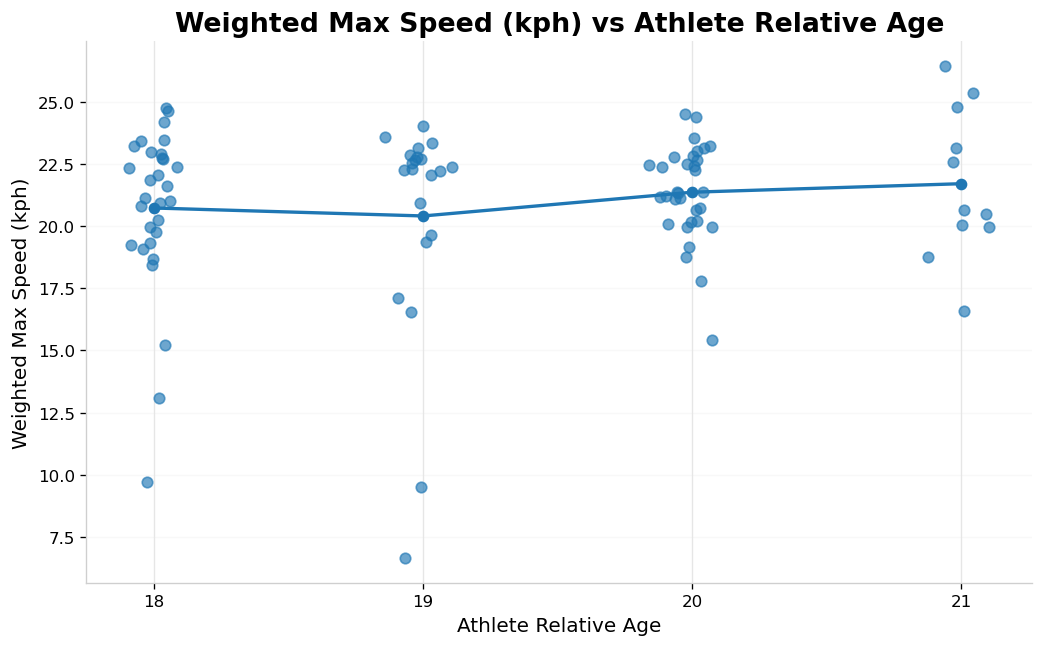

In [81]:
metrics = ["w_total_distance", "w_session_load", "w_max_speed_kph"]

for metric in metrics:
    plot_df = agg[["athlete_relative_age", metric]].dropna().copy()
    plot_df["age_jitter"] = plot_df["athlete_relative_age"] + np.random.normal(0, 0.06, len(plot_df))

    fig, ax = plt.subplots(figsize=(8.8, 5.5))

    ax.scatter(plot_df["age_jitter"], plot_df[metric], alpha=0.65, s=40)

    age_means = plot_df.groupby("athlete_relative_age")[metric].mean()
    ax.plot(age_means.index, age_means.values, marker="o", linewidth=2)

    ax.set_title(f"{label_map[metric]} vs Athlete Relative Age")
    ax.set_xlabel("Athlete Relative Age")
    ax.set_ylabel(label_map[metric])
    ax.set_xticks(ages)

    clean_axes(ax)
    plt.tight_layout()
    plt.show()

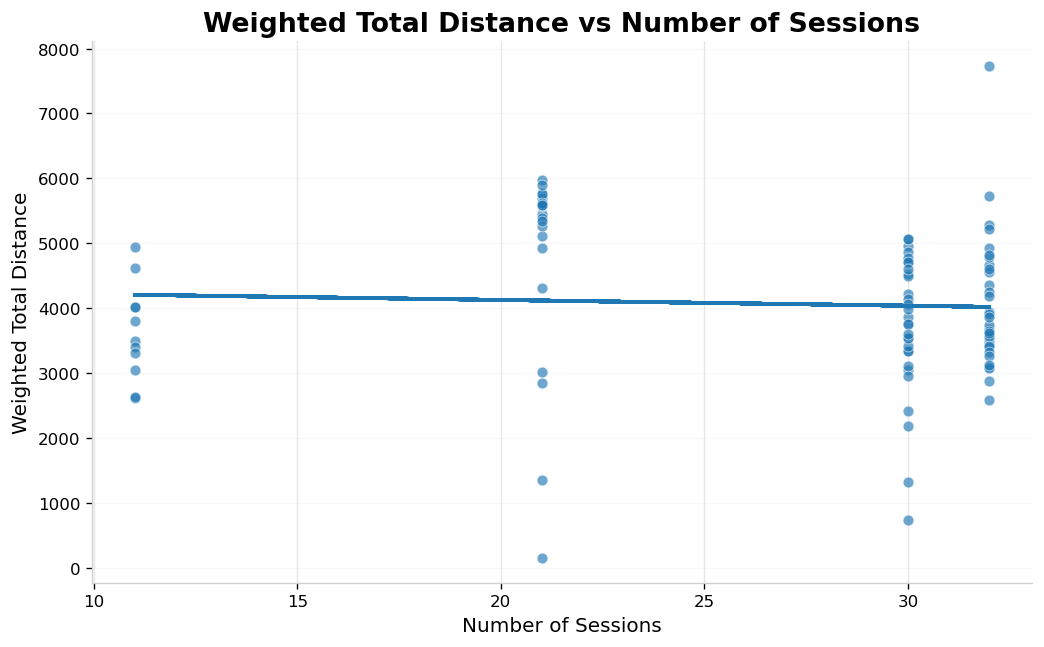

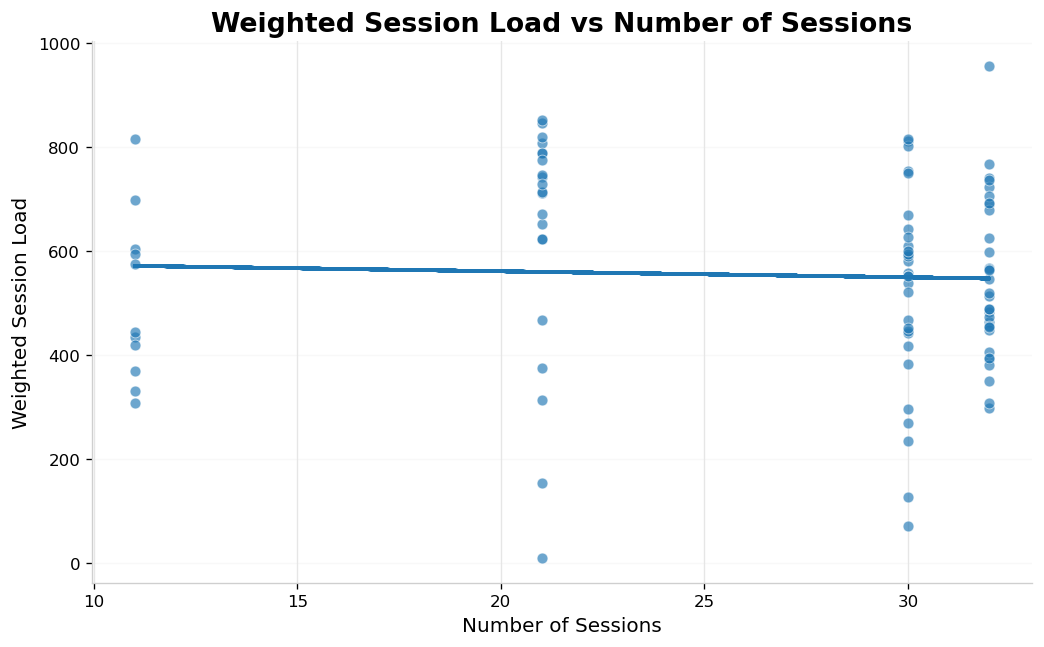

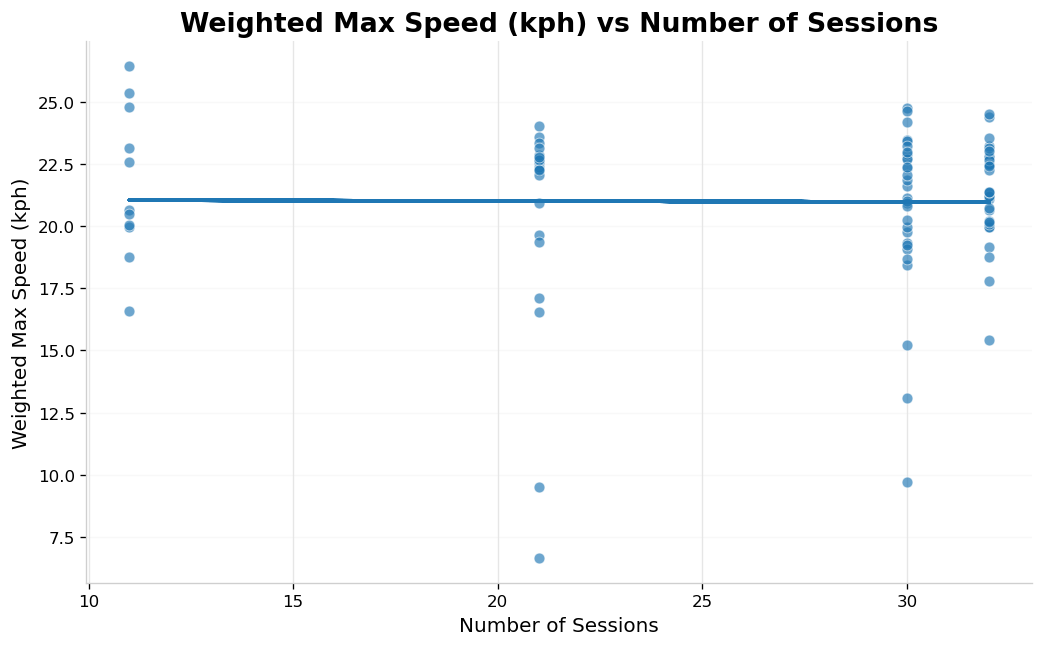

In [82]:
metrics = ["w_total_distance", "w_session_load", "w_max_speed_kph"]

for metric in metrics:
    plot_df = agg[["num_sessions", metric]].dropna()

    x = plot_df["num_sessions"]
    y = plot_df[metric]
    m, b = np.polyfit(x, y, 1)

    fig, ax = plt.subplots(figsize=(8.8, 5.5))

    ax.scatter(x, y, alpha=0.65, s=42, edgecolor="white", linewidth=0.5)
    ax.plot(x, m * x + b, linewidth=2)

    ax.set_title(f"{label_map[metric]} vs Number of Sessions")
    ax.set_xlabel("Number of Sessions")
    ax.set_ylabel(label_map[metric])

    clean_axes(ax)
    plt.tight_layout()
    plt.show()

C:\Users\bfunk\AppData\Local\Temp\ipykernel_33300\1510939035.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


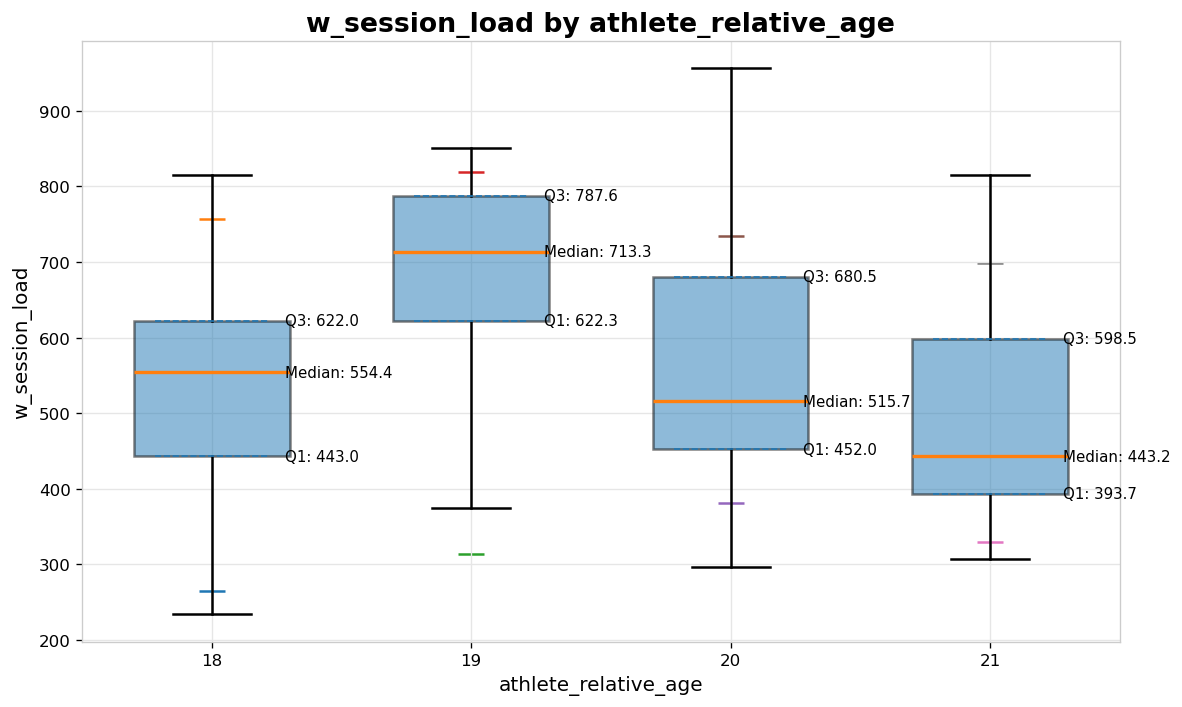

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# example structure
df = agg[["athlete_relative_age", "w_session_load"]].dropna()

group_col = "athlete_relative_age"   # category on x-axis
value_col = "w_session_load"         # numeric variable

# prepare grouped data
groups = []
labels = []

for group_value, subdf in df[[group_col, value_col]].dropna().groupby(group_col):
    groups.append(subdf[value_col].values)
    labels.append(str(group_value))

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    groups,
    labels=labels,
    patch_artist=True,
    widths=0.6,
    showfliers=False,
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

# optional box fill
for box in bp["boxes"]:
    box.set_alpha(0.5)

# annotate quartiles and median
for i, vals in enumerate(groups, start=1):
    q1 = np.percentile(vals, 25)
    median = np.percentile(vals, 50)
    q3 = np.percentile(vals, 75)
    p10 = np.percentile(vals, 10)
    p90 = np.percentile(vals, 90)

    # horizontal guide lines across each box area
    ax.hlines([q1, median, q3], i - 0.22, i + 0.22, linestyles="dashed", linewidth=1)

    # text labels
    ax.text(i + 0.28, q1, f"Q1: {q1:.1f}", va="center", fontsize=9)
    ax.text(i + 0.28, median, f"Median: {median:.1f}", va="center", fontsize=9)
    ax.text(i + 0.28, q3, f"Q3: {q3:.1f}", va="center", fontsize=9)

    # optional extra percentile markers
    ax.scatter(i, p10, marker="_", s=250, label="10th/90th" if i == 1 else "")
    ax.scatter(i, p90, marker="_", s=250)

ax.set_title(f"{value_col} by {group_col}")
ax.set_xlabel(group_col)
ax.set_ylabel(value_col)

plt.tight_layout()
plt.show()

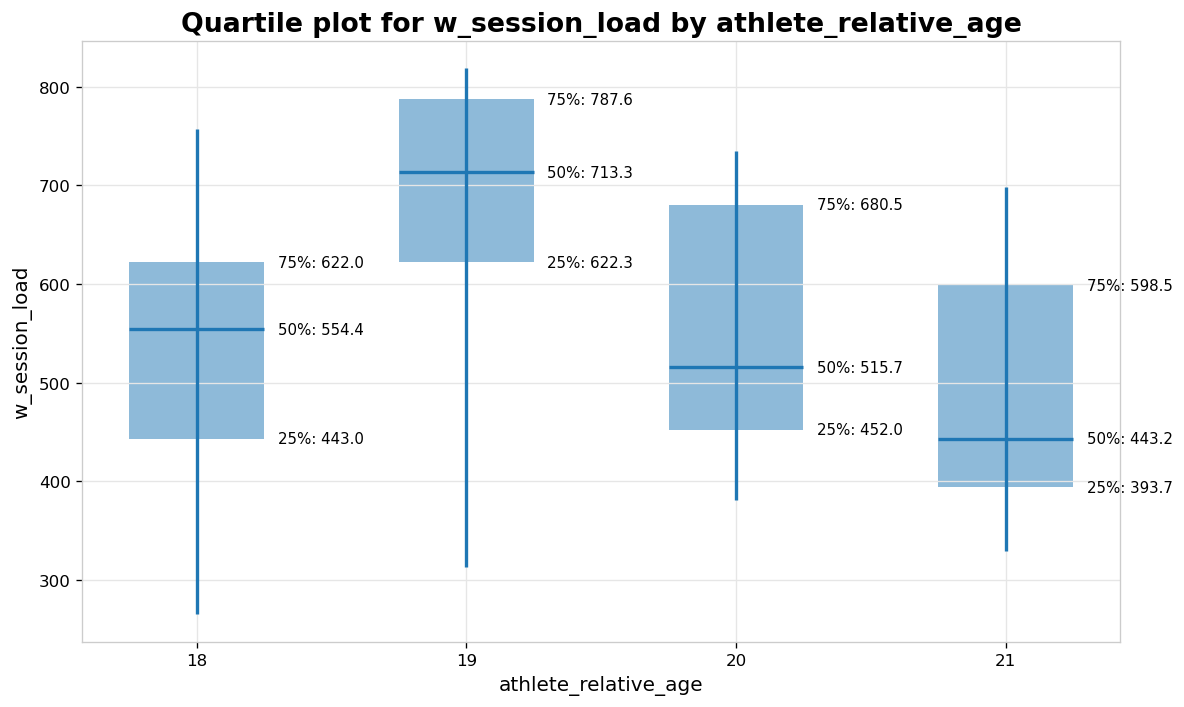

In [86]:
import numpy as np
import matplotlib.pyplot as plt

group_col = "athlete_relative_age"
value_col = "w_session_load"

summary = []

for group_value, subdf in df[[group_col, value_col]].dropna().groupby(group_col):
    vals = subdf[value_col].values
    summary.append({
        "group": group_value,
        "p10": np.percentile(vals, 10),
        "q1": np.percentile(vals, 25),
        "median": np.percentile(vals, 50),
        "q3": np.percentile(vals, 75),
        "p90": np.percentile(vals, 90),
    })

summary = sorted(summary, key=lambda x: x["group"])

x = np.arange(len(summary))

fig, ax = plt.subplots(figsize=(10, 6))

for i, s in enumerate(summary):
    # whisker-style line
    ax.vlines(i, s["p10"], s["p90"], linewidth=2)

    # IQR box
    ax.add_patch(
        plt.Rectangle(
            (i - 0.25, s["q1"]),
            0.5,
            s["q3"] - s["q1"],
            alpha=0.5
        )
    )

    # median line
    ax.hlines(s["median"], i - 0.25, i + 0.25, linewidth=2)

    # labels
    ax.text(i + 0.3, s["q1"], f"25%: {s['q1']:.1f}", va="center", fontsize=9)
    ax.text(i + 0.3, s["median"], f"50%: {s['median']:.1f}", va="center", fontsize=9)
    ax.text(i + 0.3, s["q3"], f"75%: {s['q3']:.1f}", va="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([str(s["group"]) for s in summary])
ax.set_xlabel(group_col)
ax.set_ylabel(value_col)
ax.set_title(f"Quartile plot for {value_col} by {group_col}")

plt.tight_layout()
plt.show()

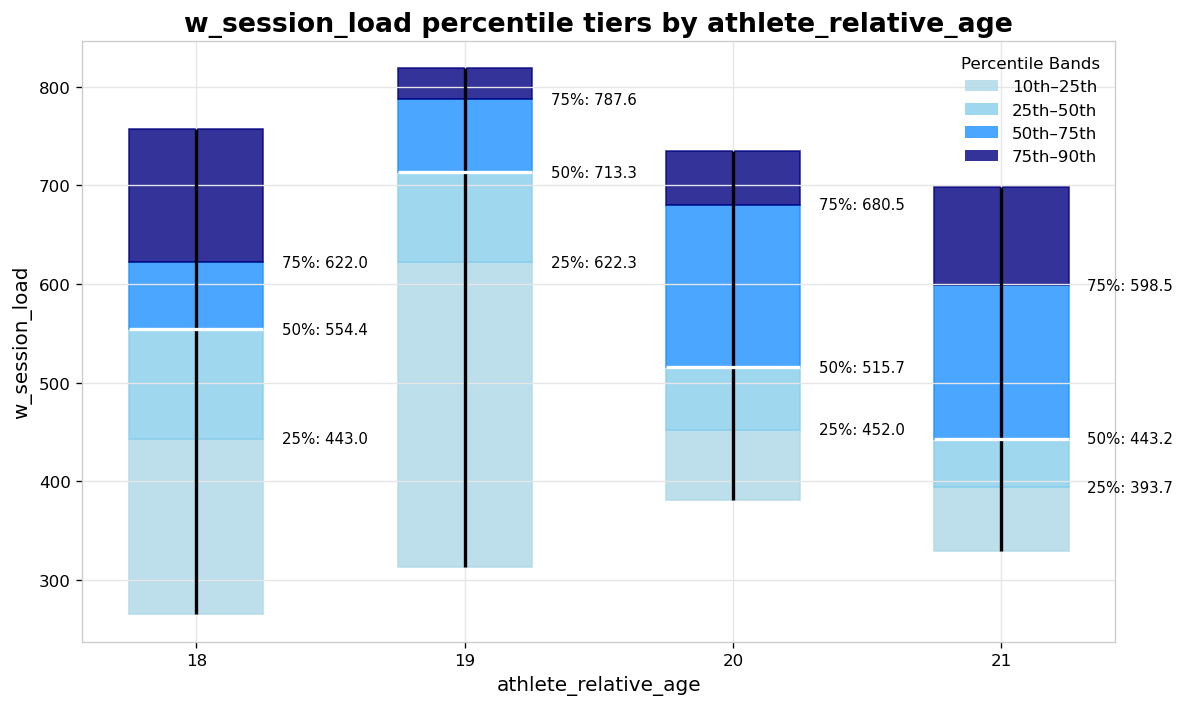

In [87]:
import numpy as np
import matplotlib.pyplot as plt

group_col = "athlete_relative_age"
value_col = "w_session_load"

summary = []

for group_value, subdf in df[[group_col, value_col]].dropna().groupby(group_col):
    vals = subdf[value_col].values
    summary.append({
        "group": group_value,
        "p10": np.percentile(vals, 10),
        "q1": np.percentile(vals, 25),
        "median": np.percentile(vals, 50),
        "q3": np.percentile(vals, 75),
        "p90": np.percentile(vals, 90),
    })

summary = sorted(summary, key=lambda x: x["group"])
x = np.arange(len(summary))

fig, ax = plt.subplots(figsize=(10, 6))

for i, s in enumerate(summary):
    # thin full range line
    ax.vlines(i, s["p10"], s["p90"], linewidth=2, color="black")

    # colored percentile tiers
    ax.add_patch(plt.Rectangle((i - 0.25, s["p10"]), 0.5, s["q1"] - s["p10"], color="lightblue", alpha=0.8))
    ax.add_patch(plt.Rectangle((i - 0.25, s["q1"]), 0.5, s["median"] - s["q1"], color="skyblue", alpha=0.8))
    ax.add_patch(plt.Rectangle((i - 0.25, s["median"]), 0.5, s["q3"] - s["median"], color="dodgerblue", alpha=0.8))
    ax.add_patch(plt.Rectangle((i - 0.25, s["q3"]), 0.5, s["p90"] - s["q3"], color="navy", alpha=0.8))

    # median line
    ax.hlines(s["median"], i - 0.25, i + 0.25, color="white", linewidth=2)

    # optional labels
    ax.text(i + 0.32, s["q1"], f"25%: {s['q1']:.1f}", va="center", fontsize=9)
    ax.text(i + 0.32, s["median"], f"50%: {s['median']:.1f}", va="center", fontsize=9)
    ax.text(i + 0.32, s["q3"], f"75%: {s['q3']:.1f}", va="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([str(s["group"]) for s in summary])
ax.set_xlabel(group_col)
ax.set_ylabel(value_col)
ax.set_title(f"{value_col} percentile tiers by {group_col}")

# custom legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="lightblue", alpha=0.8, label="10th–25th"),
    Patch(facecolor="skyblue", alpha=0.8, label="25th–50th"),
    Patch(facecolor="dodgerblue", alpha=0.8, label="50th–75th"),
    Patch(facecolor="navy", alpha=0.8, label="75th–90th"),
]
ax.legend(handles=legend_handles, title="Percentile Bands")

plt.tight_layout()
plt.show()

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
def quartile_density_plot(
    data,
    title="Quartile Distribution",
    xlabel="Value",
    show_region_labels=True
):
    x = pd.Series(data).dropna().astype(float)

    if len(x) < 5:
        print(f"Not enough data to plot: {title}")
        return

    if x.nunique() < 2:
        print(f"Not enough variation to build density curve: {title}")
        return

    # Quartiles
    q1 = x.quantile(0.25)
    q2 = x.quantile(0.50)   # median
    q3 = x.quantile(0.75)

    # KDE curve
    kde = gaussian_kde(x)
    spread = x.max() - x.min()
    pad = spread * 0.20 if spread > 0 else 1
    xs = np.linspace(x.min() - pad, x.max() + pad, 600)
    ys = kde(xs)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Outline of the curve
    ax.plot(xs, ys, color="#0B4F9C", linewidth=2)

    # Fill quartile regions
    regions = [
        (xs <= q1, "lightblue"),                 # left tail / Q1 region
        ((xs > q1) & (xs <= q2), "#87CEEB"),  # Q2 region
        ((xs > q2) & (xs <= q3), "#1E90FF"),  # Q3 region
        (xs > q3, "navy")                  # right tail / Q4 region
    ]

    for mask, color in regions:
        ax.fill_between(xs, ys, where=mask, color=color, alpha=0.95)

    # Vertical quartile lines
    ax.axvline(q1, color="black", linewidth=1.3)
    ax.axvline(q2, color="black", linewidth=1.6)
    ax.axvline(q3, color="black", linewidth=1.3)


    # Region labels (each quartile = 25%)
    if show_region_labels:
        legend_handles = [
            Patch(facecolor="lightblue", edgecolor="none", label="Q1 (0%-25%)"),
            Patch(facecolor="skyblue", edgecolor="none", label="Q2 (25%-50%)"),
            Patch(facecolor="dodgerblue", edgecolor="none", label="Q3 (50%-75%)"),
            Patch(facecolor="navy", edgecolor="none", label="Q4 (75%-100%)"),
        ]

    ax.legend(
        handles=legend_handles,
        title="Quartiles",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.10),
        ncol=4,
        frameon=False,
        fontsize=9,
        title_fontsize=10
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")

    # Clean look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_yticks([])
    ax.grid(False)

    plt.tight_layout()
    plt.show()

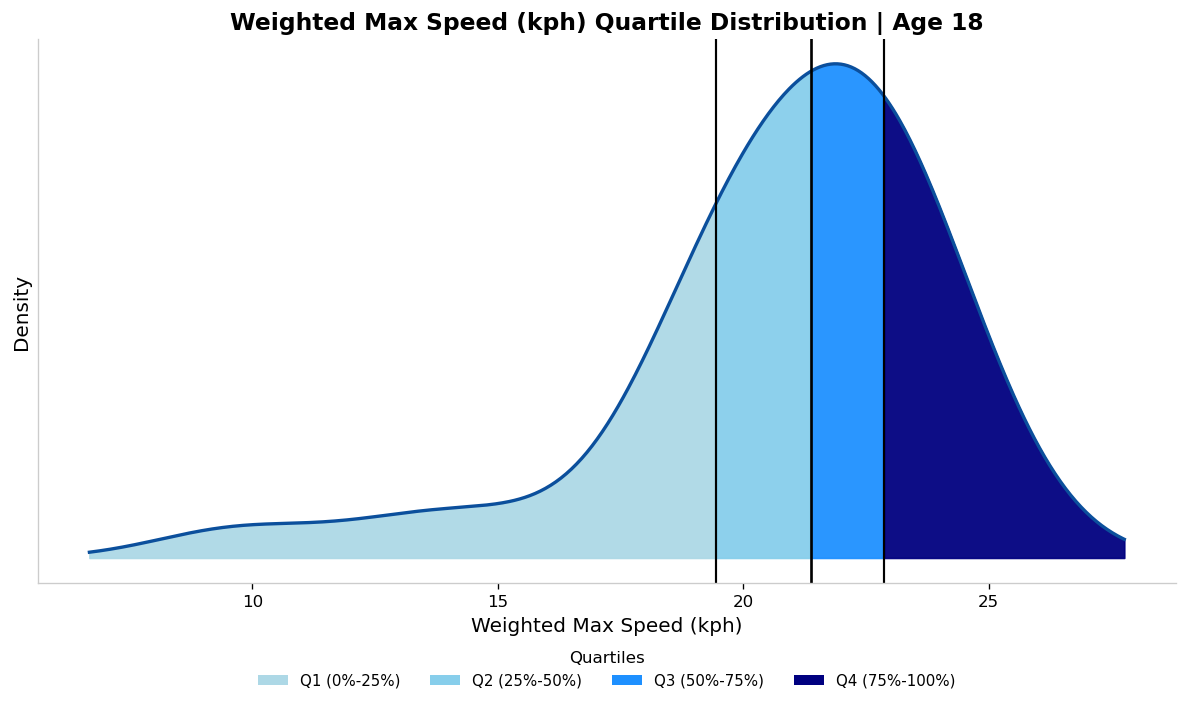

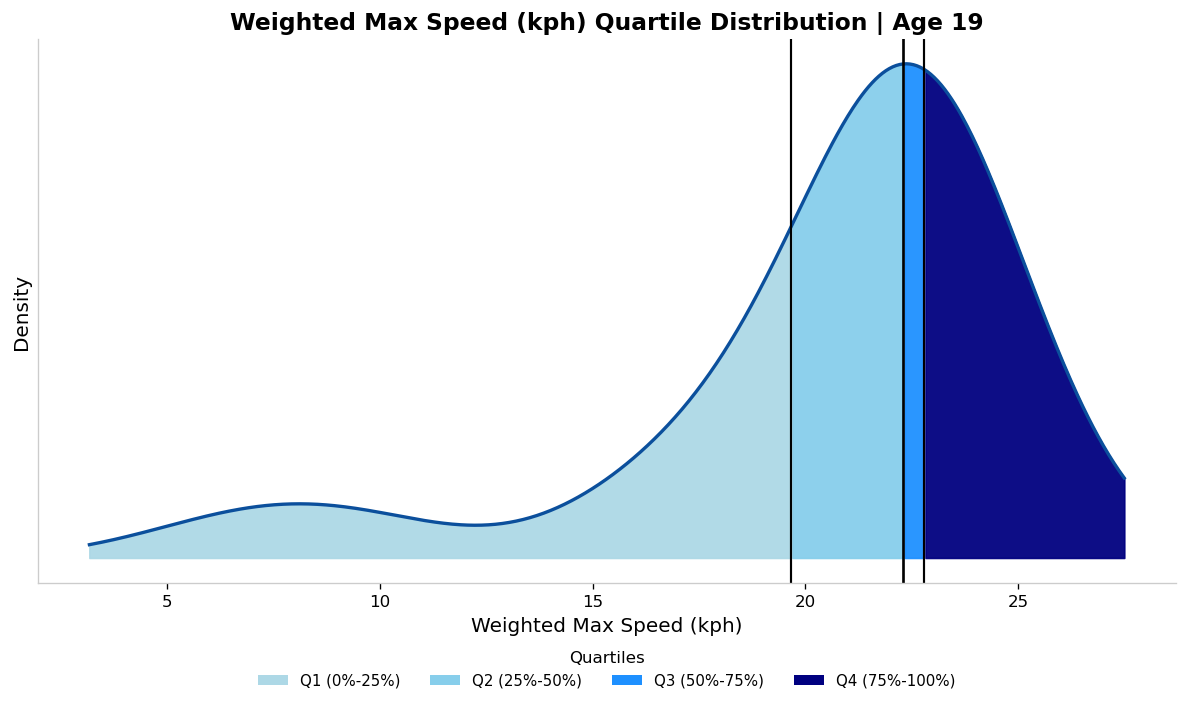

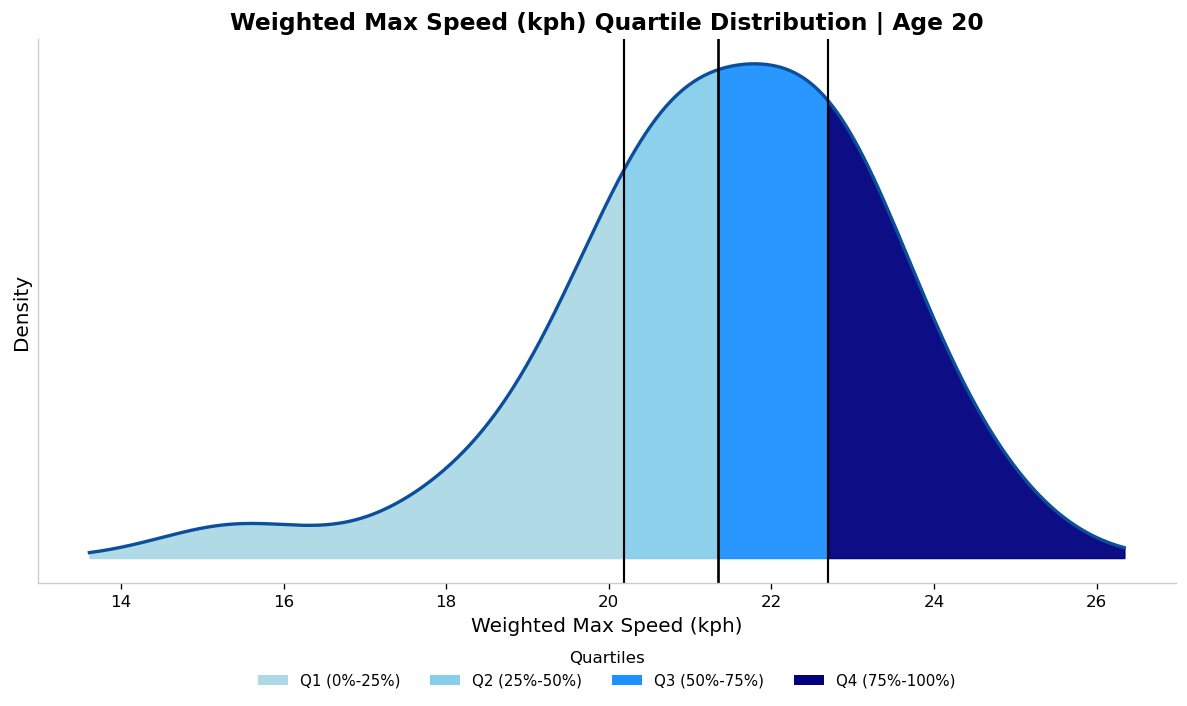

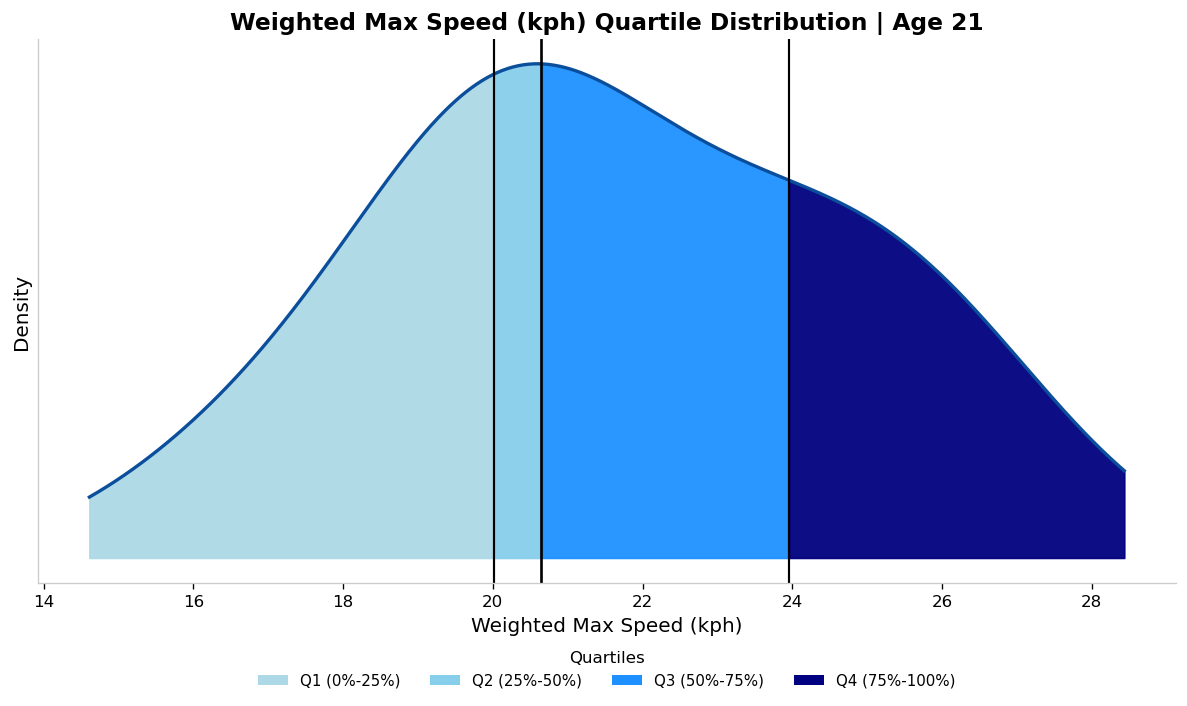

In [118]:
ages = sorted(agg["athlete_relative_age"].dropna().unique())
metric = "w_max_speed_kph"

for age in ages:
    age_data = agg.loc[agg["athlete_relative_age"] == age, metric].dropna()

    quartile_density_plot(
        age_data,
        title=f"{label_map[metric]} Quartile Distribution | Age {int(age)}",
        xlabel=label_map[metric]
    )